# note 
for loan limit if income was not imputed loan limit = income + credit score and must be smaller thant loan amount 

# Business problem:


# advantage 

# ML problem type 

# hypothese 
- Higher debt-to-income ratios may increase default risk
- Lower credit scores may correlate with higher defaults
- High LTV loans may be riskier
- Certain loan purposes may have elevated default rates

# Import library

In [150]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Function definition

In [151]:
#function to make data exploration for numeric features 
def num_eda(df,column,bin="auto"):

    # print the percentage of null variable 
    print (f"{column} have {(df[column].isna().mean()*100)}% of null variable ")
    # check if null values are predictive 
    if df[column].isna().mean()*100>0:
        
        print(df.groupby(df[column].isnull())["Status"].mean())

    ################################################################
    #################### numerical features ########################
    ################################################################
    
    if pd.api.types.is_numeric_dtype(df[column]):

   
        # print basic stats
        print(df[column].describe())
        # plot histogram
        plt.figure(figsize=(10,8))
        df[column].hist(bins=bin)
        plt.title(f'{column} Distribution')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show()


        # plot boxplot
        plt.figure(figsize=(10,8))
        sns.boxplot(x=df[column])
        plt.title(f'{column} Boxplot')
        plt.show()

    
        ####comparison vs status#############
        

        # hiatogram
        sns.histplot(data=df, x=column, hue="Status")
        plt.title(f'{column} vs status distribution')
        plt.show()
        # box plot 
        sns.boxplot(x="Status", y=column, data=df)
        plt.title(f'{column} vs status Boxplot')
        plt.show()

    #########################################################
    ################categorical features#####################
    #########################################################
    else:
       # plot a bar chart 
       df[column].value_counts(dropna=False).plot(kind="bar")
       plt.title(f"{column} distribution")
       plt.show() 
       #######comparison vs status###########
       sns.countplot(x=column, hue='Status', data=df)
       plt.title(f"{column} vs status distribution")
       plt.show() 


# Import dataset 

In [152]:

# df=pd.read_csv("Loan_Default.csv")
df = pd.read_csv("../data/Loan_Default.csv")

<!-- ## data exploration  -->

# Data Exploration

In [153]:
# look at the general info on the dataset 
print (df.shape)
print(df.info())

(148670, 34)
<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            

* this part show that we have a dataset of 33 columns and 148670, but some column have less non null values , which mean that the data set have missing values in several columns .
* the dataset contain also several columns  of different data type, it have 21 string columns, 4 integer colums and 8 float columns

In [154]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


* this part show basic stats about the dataset 

<Axes: >

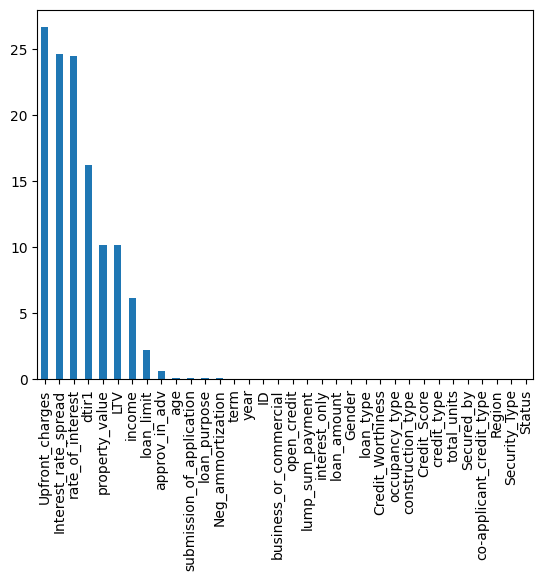

In [155]:
# make a visualisation which illustrate the percentage of missing value per columns
missing = df.isnull().mean().sort_values(ascending=False)*100
missing.plot(kind='bar')

+ part show the percentage of missing values each column have.
this is usefull as most machine learning model do not work properly with dataset that have missing value , handling these values become crucial 
* using a graph to illustrate the percentage of missing values each column have gives a clearer idea on how to handle the missing values without making the dataset too bias 
* for example column upfront_charges will be drop as it contain over 25% of its value missing  

* **Status**

In [156]:
df["Status"].unique()# confirm that there is only 2 posible status 


array([1, 0])

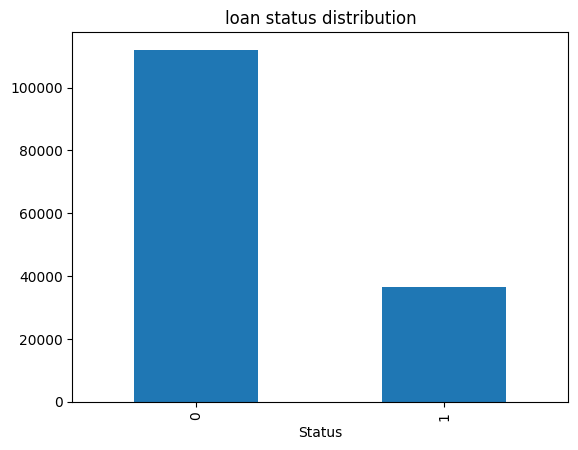

In [157]:

df["Status"].value_counts(dropna=False).plot(kind="bar")
plt.title("loan status distribution")
plt.show()

 this graph show that the dataset we are using is imbalance 

* **ID**

In [158]:
# make sure their are no duplicate loans in the data set 
print(df["ID"].duplicated().sum())

0


* **Year**

In [159]:
# check the maximum and the minimum year to check if there is any erros.
# result show that there is only one year which is 2019 so the column year is useless for our prediction
print(df["year"].max())
print(df["year"].min())
print(df["year"].unique())

2019
2019
[2019]


In [160]:
df=df.drop(columns="year")

# numerical columns

* **Income**

income have 6.154570525324544% of null variable 
income
False    0.253727
True     0.135410
Name: Status, dtype: float64
count    139520.000000
mean       6957.338876
std        6496.586382
min           0.000000
25%        3720.000000
50%        5760.000000
75%        8520.000000
max      578580.000000
Name: income, dtype: float64


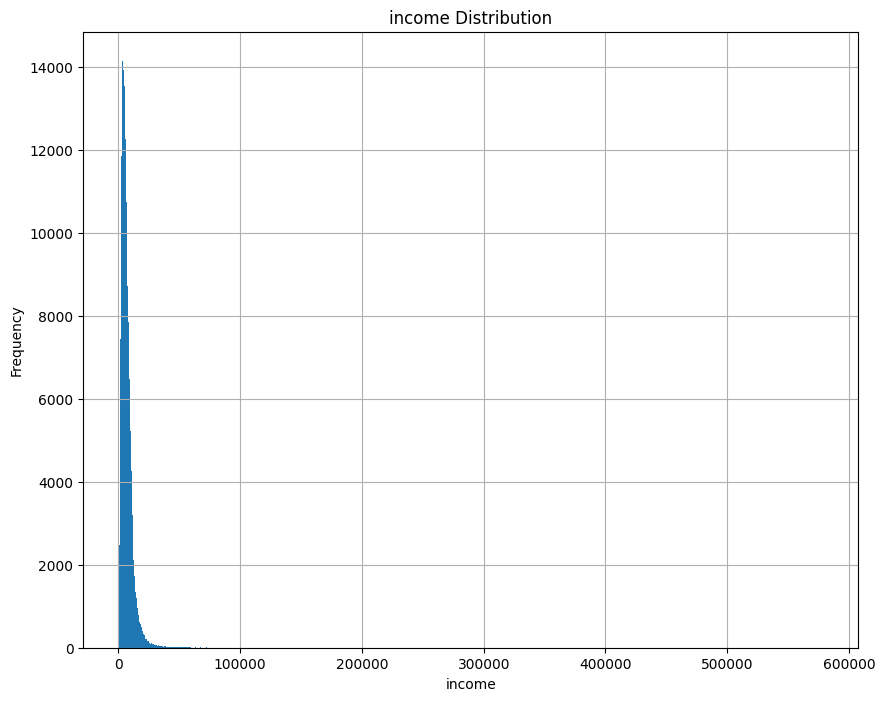

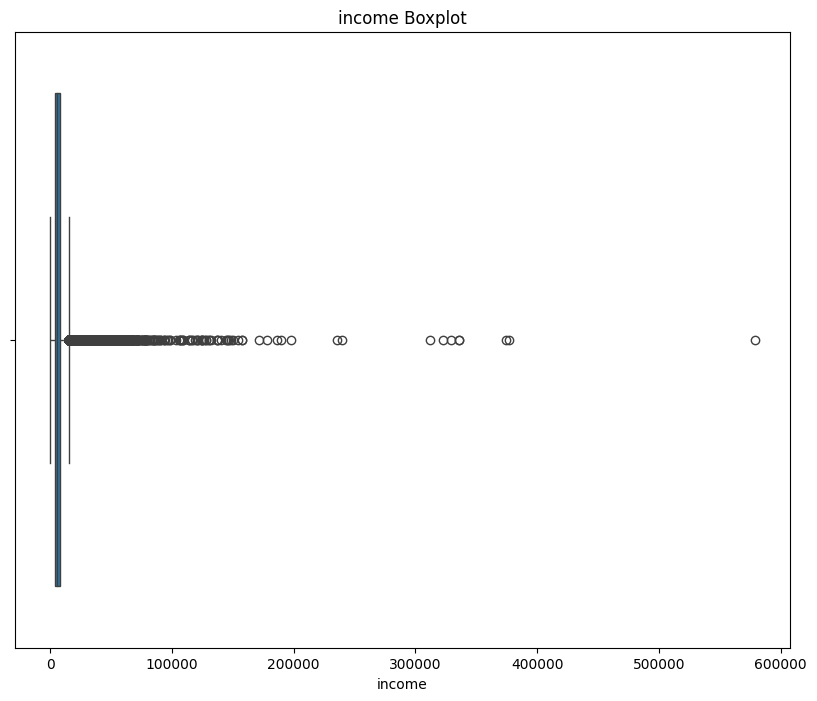

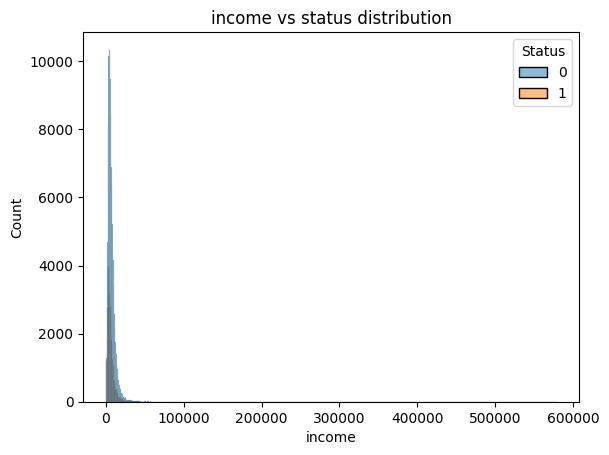

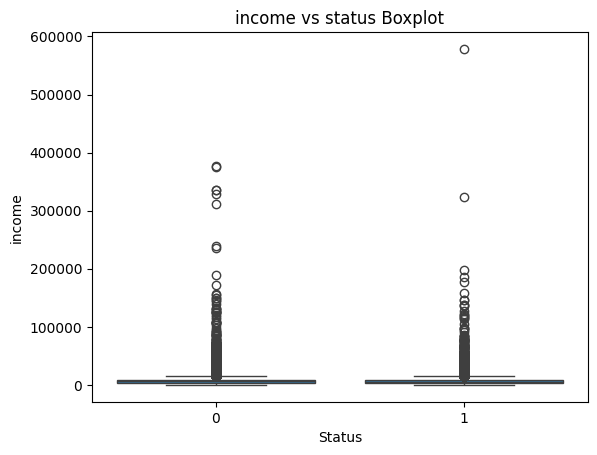

In [161]:
num_eda(df,"income")

**Basic stat**
* this show that income distribution apppear to be right skewed and have a hight variability
* the large difference between the mean and the meadian suggest the presence of outlier 
* also although 75% of the income are below 8520 the maximun income is 578580, this inducate strong outlier 

**Histogram**

* the histogram confirm that income is positively skewed  
* most income are concentrated closer to the lower income range

**boxplot**

* the box plot confirm that income have strongs outliers 

**Summary:**

+ The income distribution is highly right-skewed and have significant outliers, this suggest  that a small number of borrowers have an extrimely high income. 

**what are the problem:**
* the model might overfit rare high incomes ( that is if only  5 people have high income and did not default the model might just interpret it as high income always mean safe loan  )
* the mean is distorted by outliers 
* less than 10% missing values 

**Proposed solution**

* log transformation of the income 
* impute missing values using median
* add a missing income indicator as missing income might be  predictive, that is  borrower hiding their income may be higher risk.

**Income vs status**
* the distribution of both classes (default and non default) overlap, this indicate there is no clear income threshold which seperate defaulter from non defaulter.




* **Loan amount**

loan_amount have 0.0% of null variable 
count    1.486700e+05
mean     3.311177e+05
std      1.839093e+05
min      1.650000e+04
25%      1.965000e+05
50%      2.965000e+05
75%      4.365000e+05
max      3.576500e+06
Name: loan_amount, dtype: float64


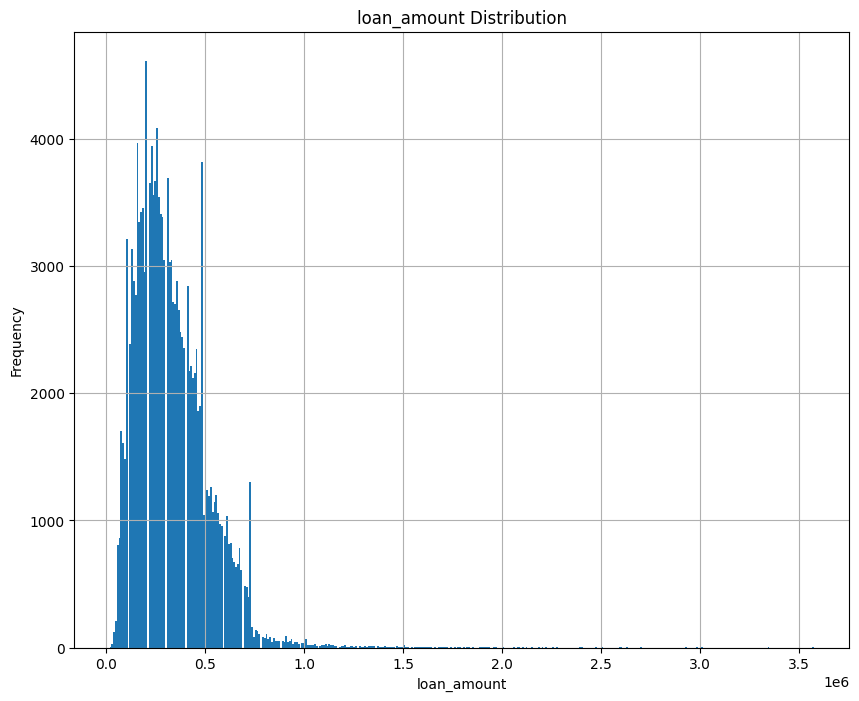

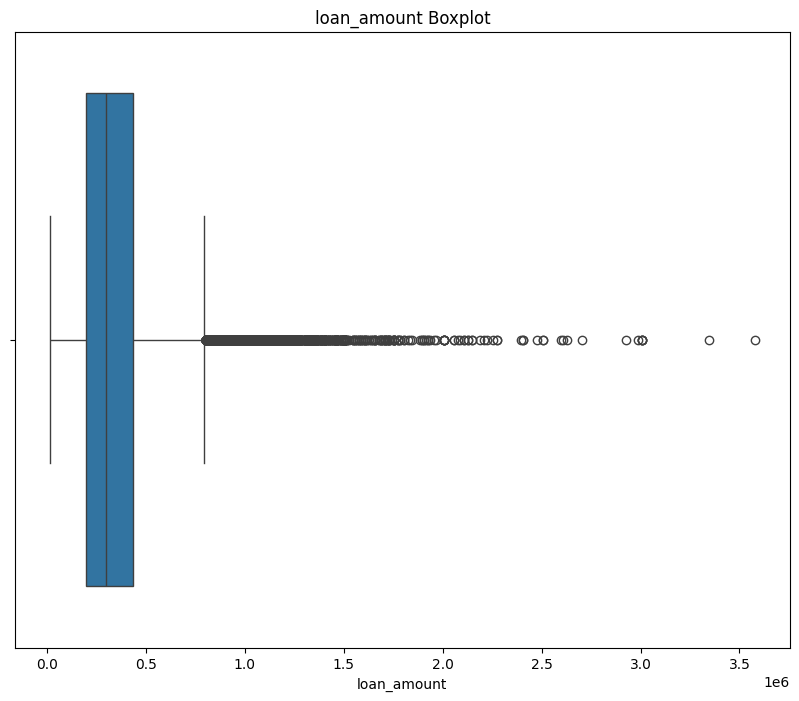

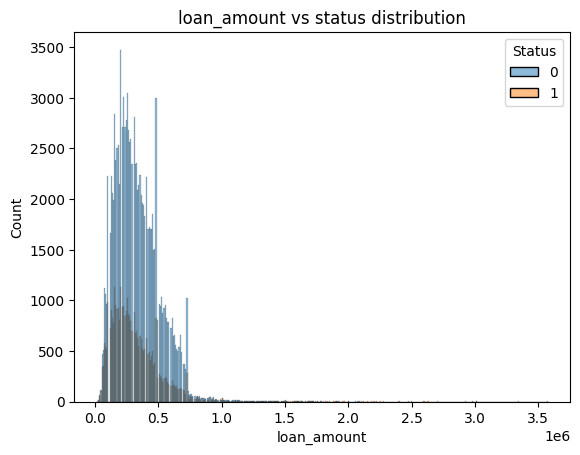

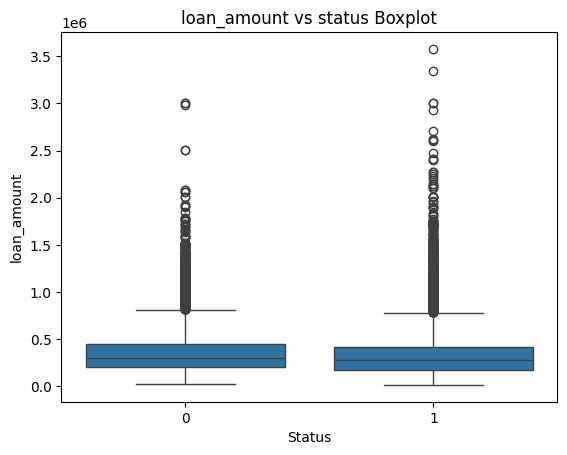

In [162]:
num_eda(df,"loan_amount")

**Basic stat**
* this show that loan_amount distribution  apppear to be right skewed 
* the noticable diffrence between the mean and the meadian suggest the presence of outlier which pull up the mean 
* the standard deviation is very large relative to the mean , this suggest considerable dispersion in loan sizes across borrowers. 

**Histogram**

* the histogram confirm that loan amount  is positively skewed  
* most borrower get small to moderate loan and a very low amount of borrowers take large loan 
* the histogram also show that loan amount are  heterogenous which suggest that they might be multiple different subclass of borrower

**boxplot**

* the box plot confirm that there are extreme outlier case 

**Summary:**

+ Loan amount distribution is highly heterogenous, right-skewed and have significant outliers, this suggest first they migh be different subclasses of borrowers and  that a smaller number of borrowers have an extrimely high loans 

**Proposed solution**
* use Kernel density estimation to confirm if their are multiple subclass
* loan amount might also need log transformation 

**loan amount  vs status**
* as for the income the distribution of both classes (default and non default) overlap, this indicate there is no clear loan amount threshold which seperate defaulter from non defaulter.



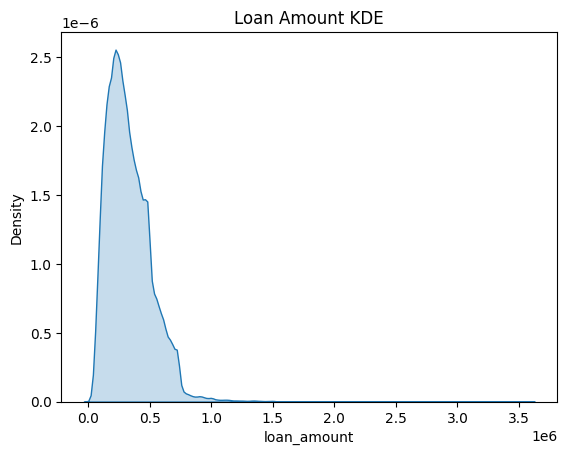

In [163]:
sns.kdeplot(df["loan_amount"], fill=True)
plt.title("Loan Amount KDE")
plt.show()

the kde give a clearer view on the distribution. it shows that  while minor fluctuations are present, there is limited evidence of clearly separated multimodal structure.

* **Credit_Score**

Credit_Score have 0.0% of null variable 
count    148670.000000
mean        699.789103
std         115.875857
min         500.000000
25%         599.000000
50%         699.000000
75%         800.000000
max         900.000000
Name: Credit_Score, dtype: float64


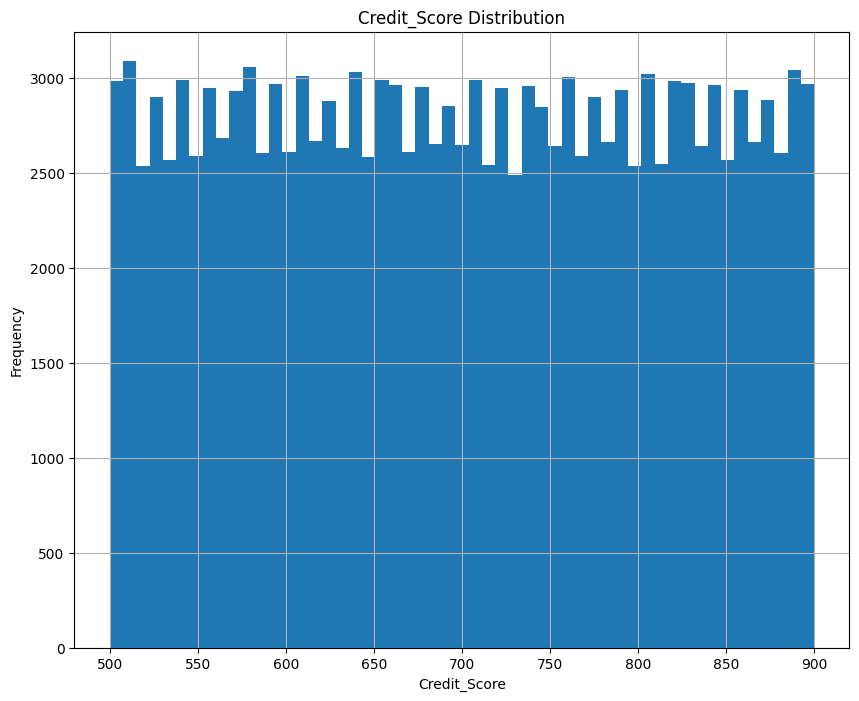

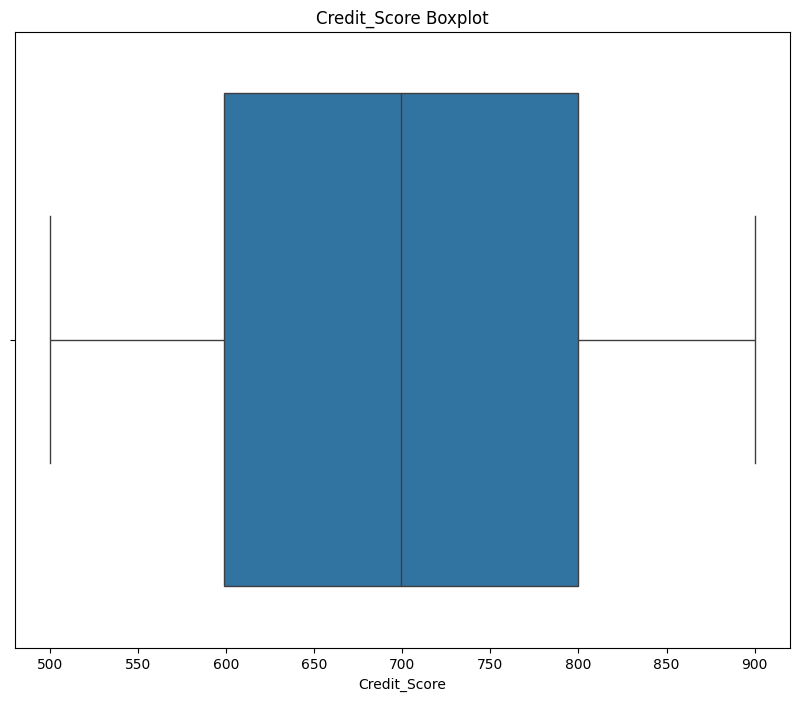

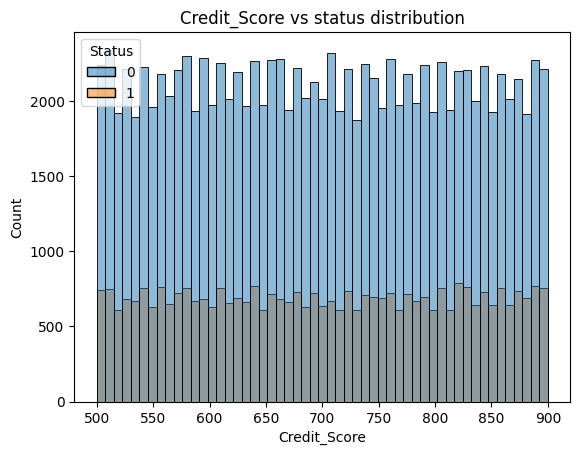

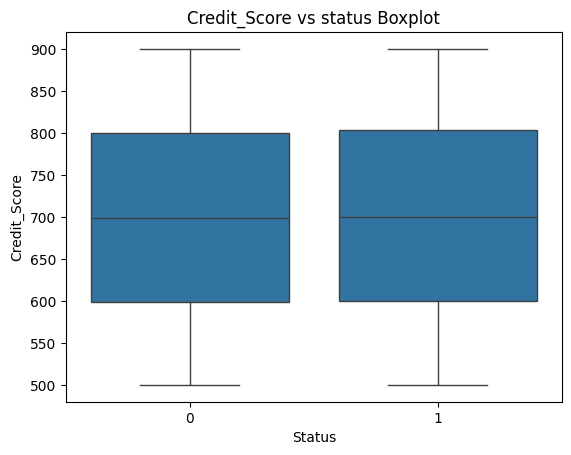

In [164]:
num_eda(df,"Credit_Score")

* Basic stat and histogram confirm that there is no strong skewness  
* credit scores are uniformly distribute across 500 to 900
* there is no outlier 
*  both classes (default and non default) overlap, this indicate there is no clear credit score threshold which seperate defaulter from non defaulter.

*  **rate_of_interest**

rate_of_interest have 24.509988565278807% of null variable 
rate_of_interest
False    0.001782
True     1.000000
Name: Status, dtype: float64
count    112231.000000
mean          4.045476
std           0.561391
min           0.000000
25%           3.625000
50%           3.990000
75%           4.375000
max           8.000000
Name: rate_of_interest, dtype: float64


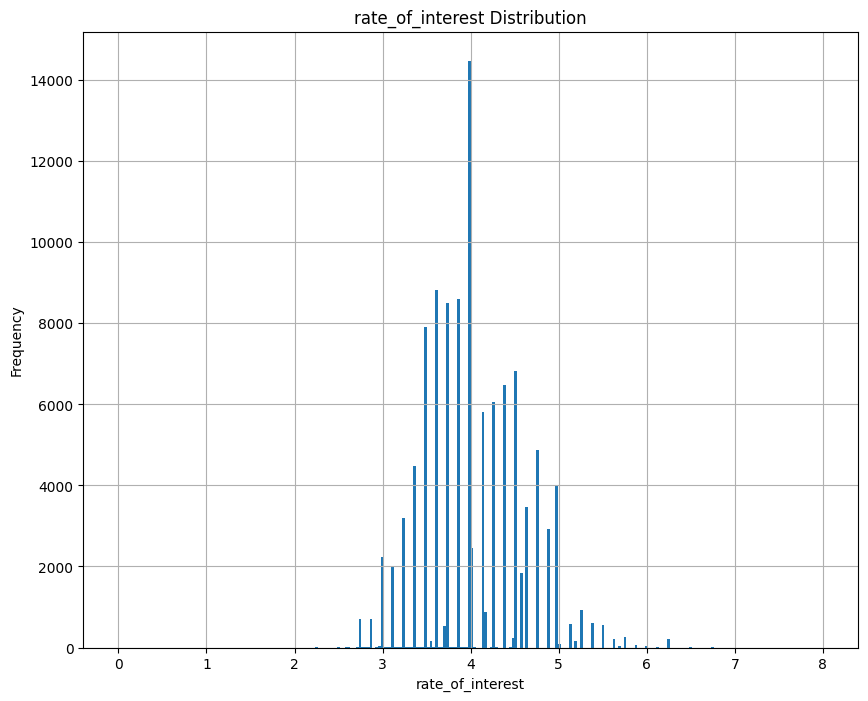

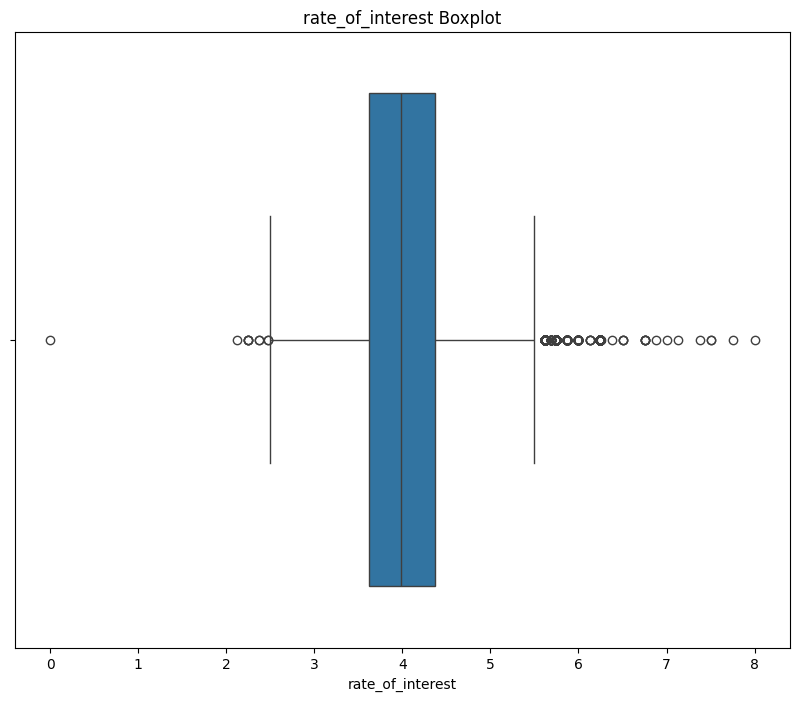

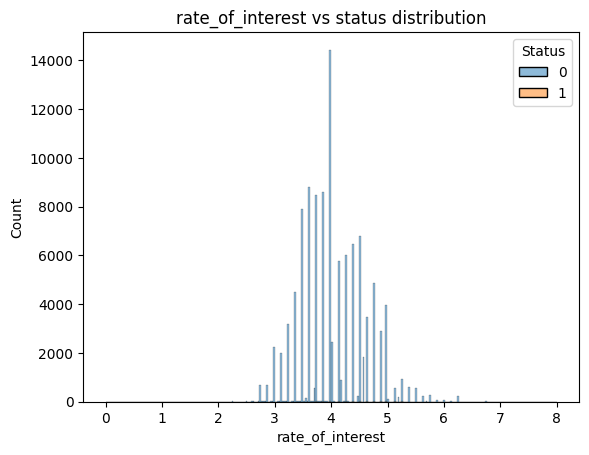

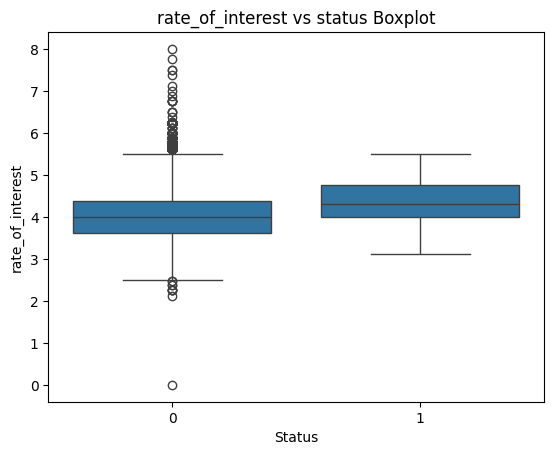

In [165]:
num_eda(df,"rate_of_interest")

**Basic stat**
* the minimum interest rate is zero which suggest an error 
*  the mean is sligtly higher than the median this suggest that the distribution is positively skewed 

result show data leakage as missing interest rate serve as a proxy for default. this column will be removed from the data set .







In [166]:
pd.crosstab(
    df["rate_of_interest"].isnull(),
    df["Status"]
)


Status,0,1
rate_of_interest,,
False,112031,200
True,0,36439


* **Interest_rate_spread**

Interest_rate_spread have 24.64451469697989% of null variable 
Interest_rate_spread
False    0.0
True     1.0
Name: Status, dtype: float64
count    112031.000000
mean          0.441656
std           0.513043
min          -3.638000
25%           0.076000
50%           0.390400
75%           0.775400
max           3.357000
Name: Interest_rate_spread, dtype: float64


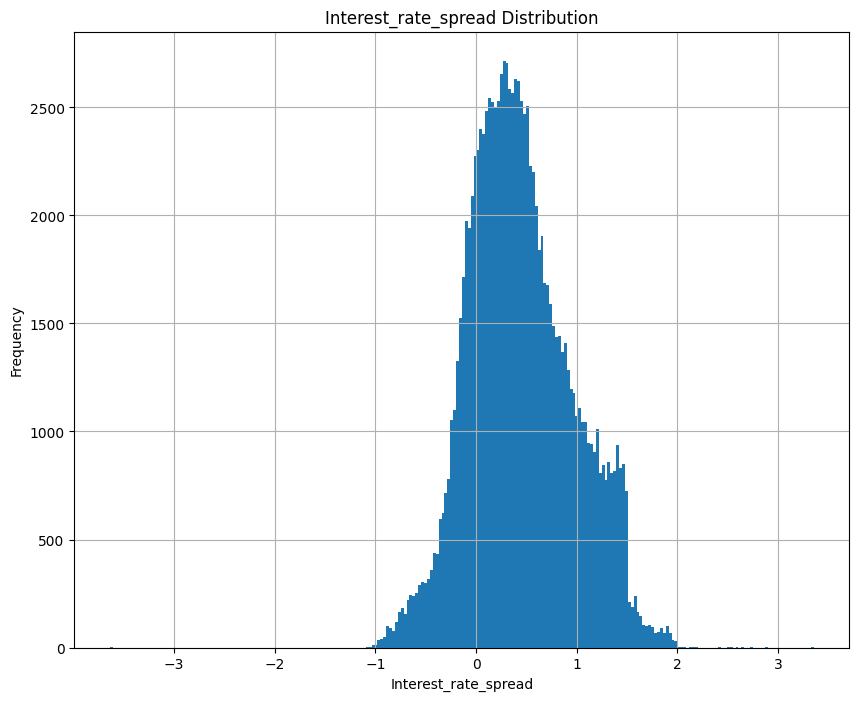

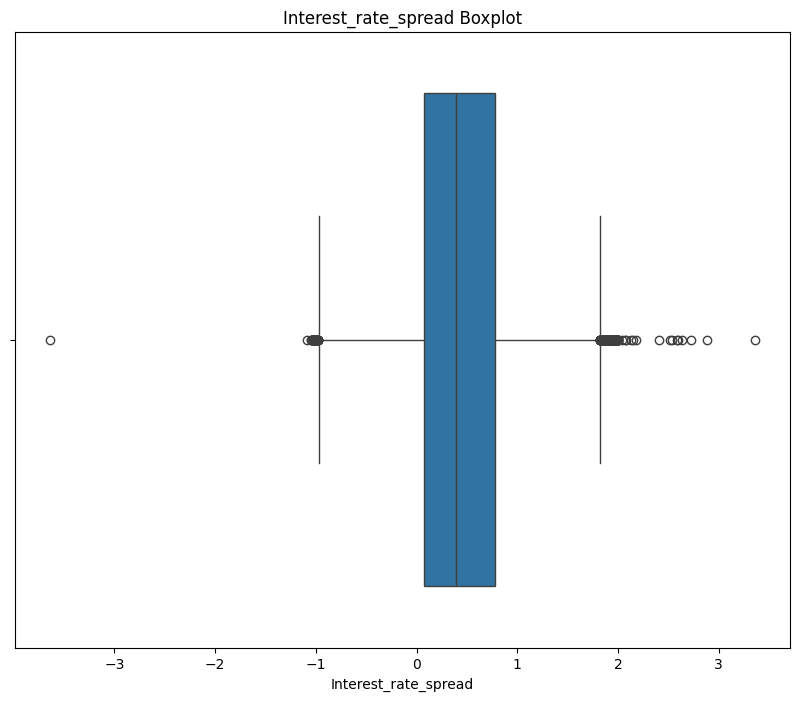

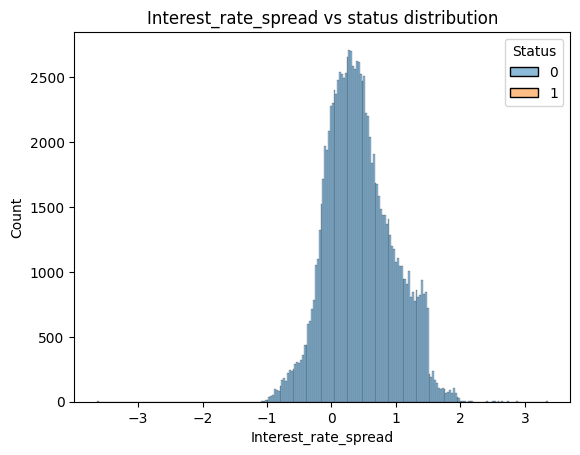

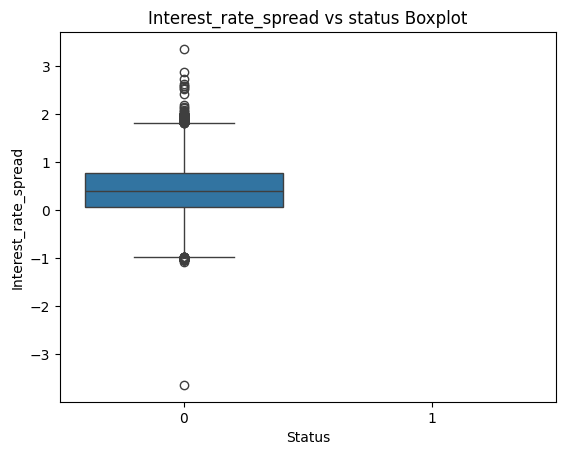

In [167]:
num_eda(df,"Interest_rate_spread")

result show data leakage as missing interest rate spread serve as a proxy for default. this column will be removed from the data set .

* **Upfront_charges**

Upfront_charges have 26.664424564471652% of null variable 
Upfront_charges
False    0.001403
True     0.920387
Name: Status, dtype: float64
count    109028.000000
mean       3224.996127
std        3251.121510
min           0.000000
25%         581.490000
50%        2596.450000
75%        4812.500000
max       60000.000000
Name: Upfront_charges, dtype: float64


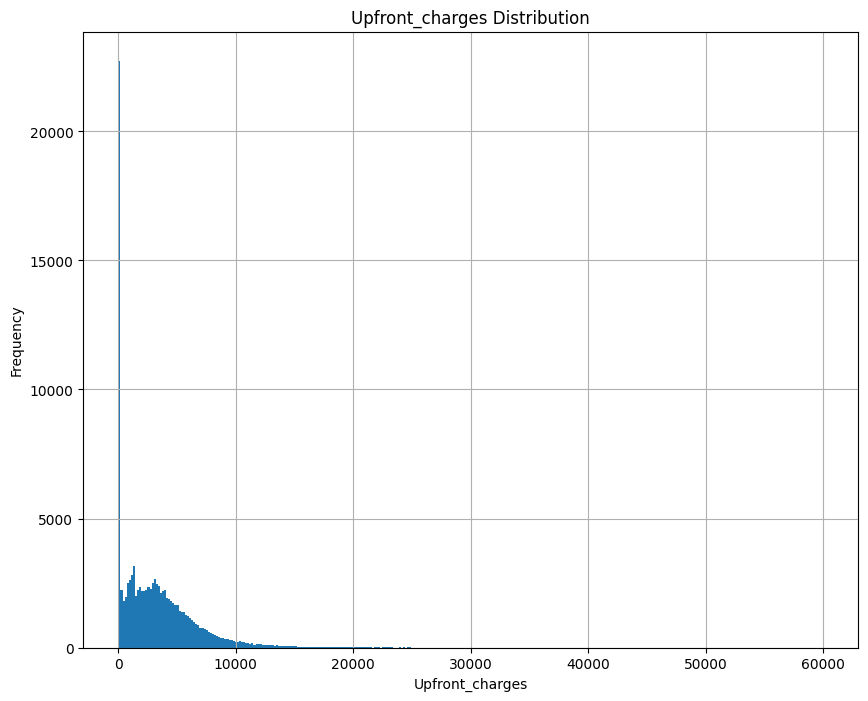

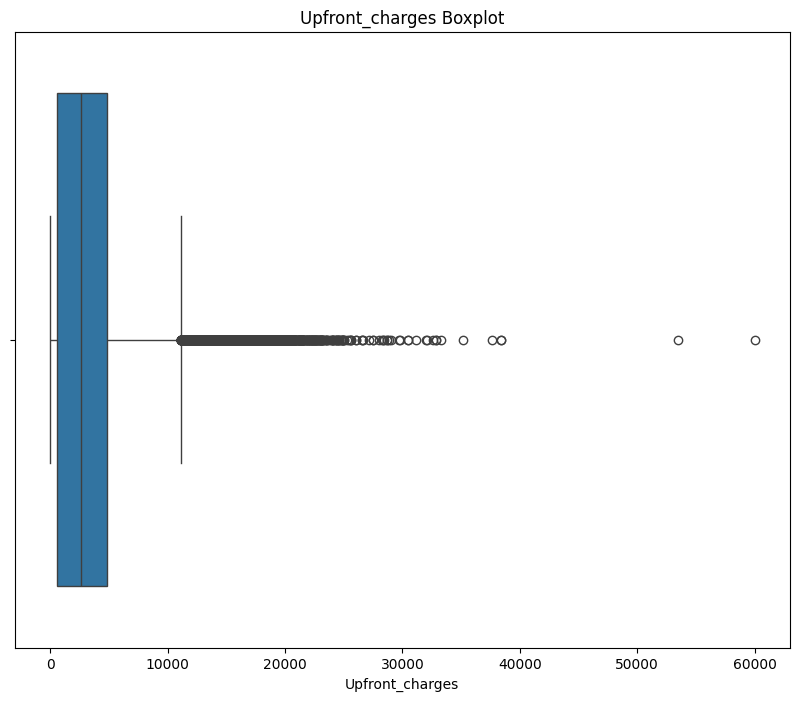

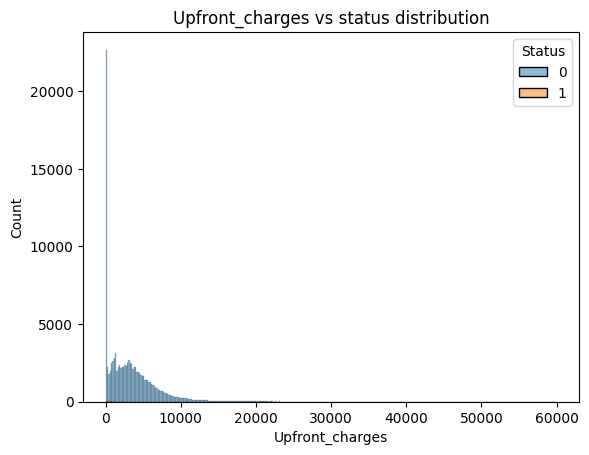

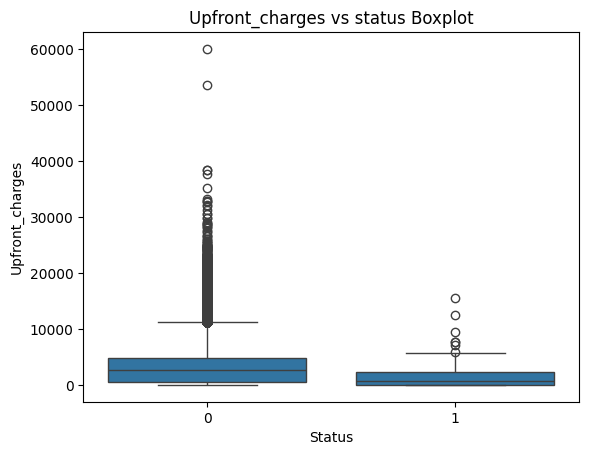

In [168]:
num_eda(df,"Upfront_charges")

result show data leakage as missing Upfront_charges serve as a proxy for default. this column will be removed from the data set .

* **property_value**

property_value have 10.15537768211475% of null variable 
property_value
False    0.161284
True     0.999868
Name: Status, dtype: float64
count    1.335720e+05
mean     4.978935e+05
std      3.599353e+05
min      8.000000e+03
25%      2.680000e+05
50%      4.180000e+05
75%      6.280000e+05
max      1.650800e+07
Name: property_value, dtype: float64


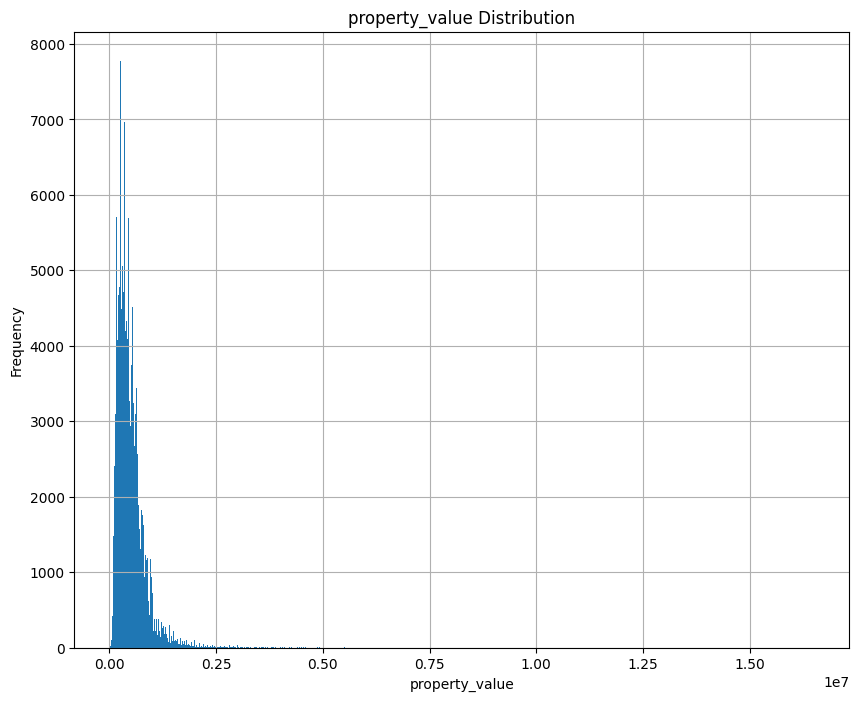

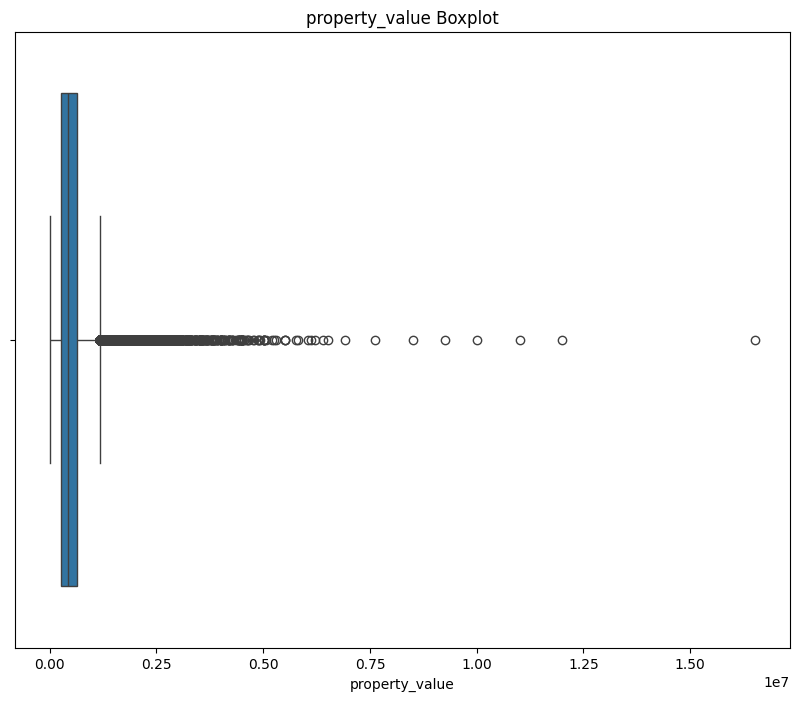

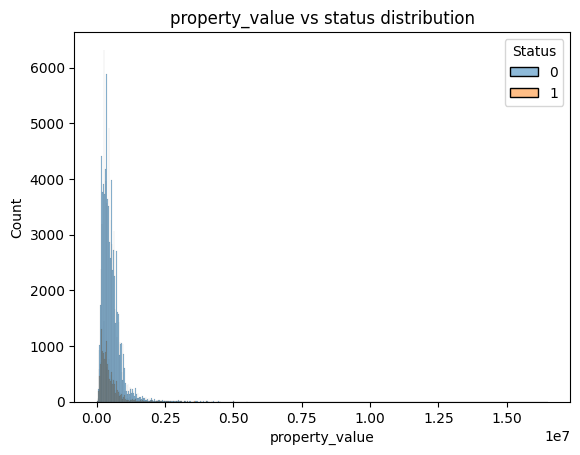

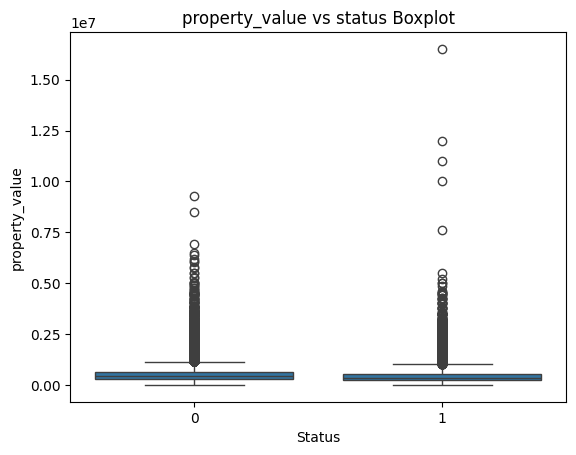

In [169]:
num_eda(df,"property_value")

result show data leakage as missing property value serve as a proxy for default. this column will be removed from the data set .

*  **LTV**

LTV have 10.15537768211475% of null variable 
LTV
False    0.161284
True     0.999868
Name: Status, dtype: float64
count    133572.000000
mean         72.746457
std          39.967603
min           0.967478
25%          60.474860
50%          75.135870
75%          86.184211
max        7831.250000
Name: LTV, dtype: float64


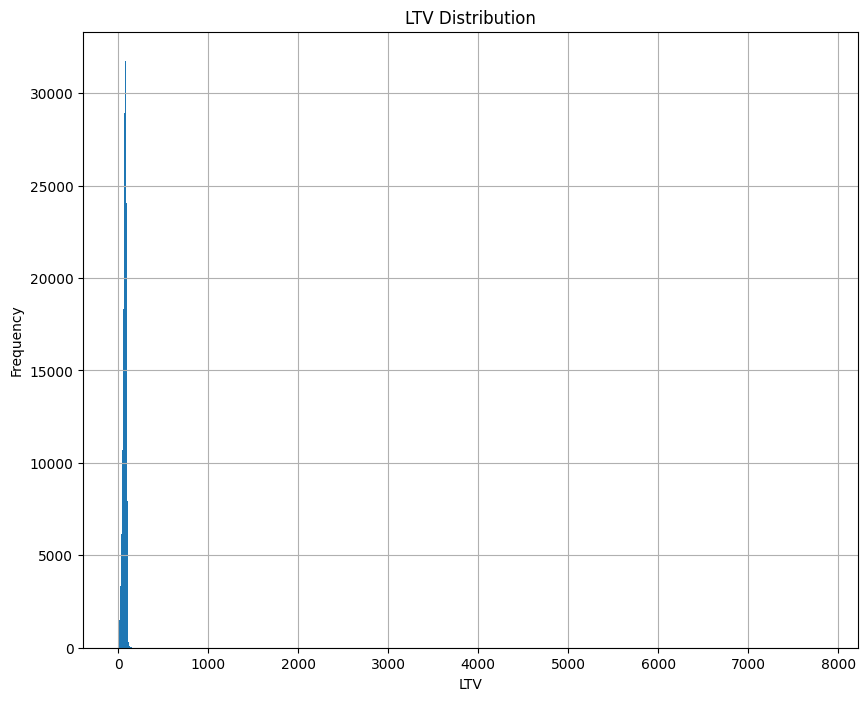

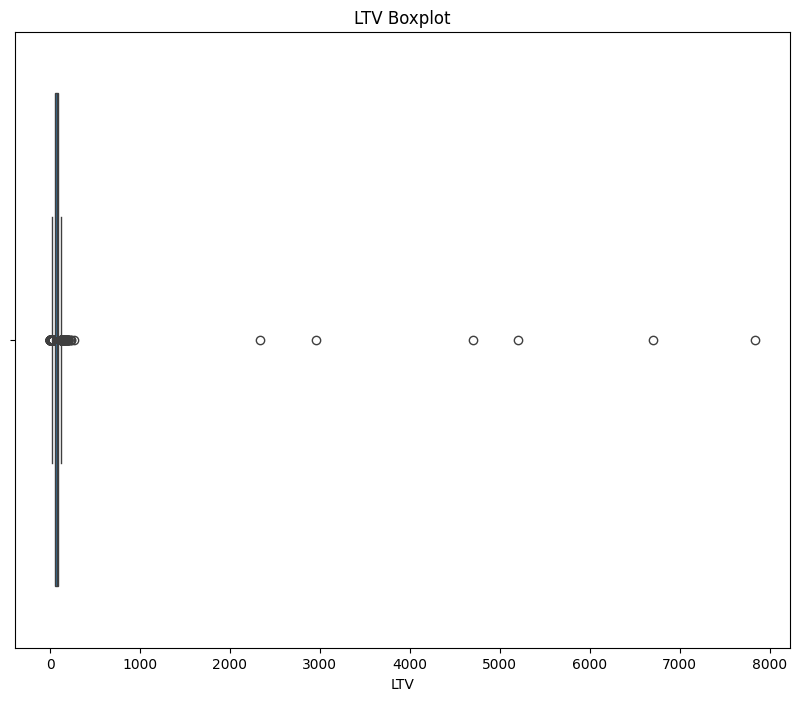

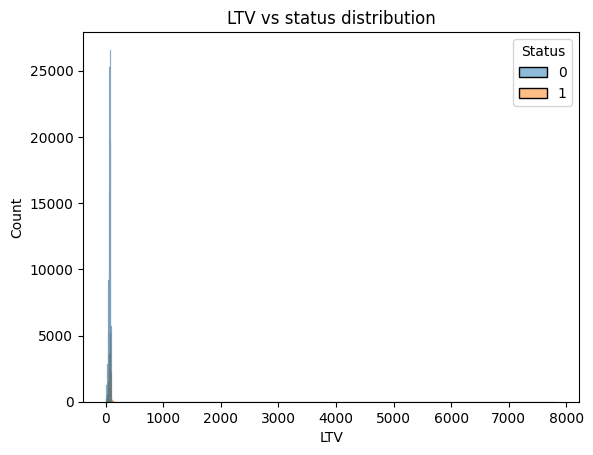

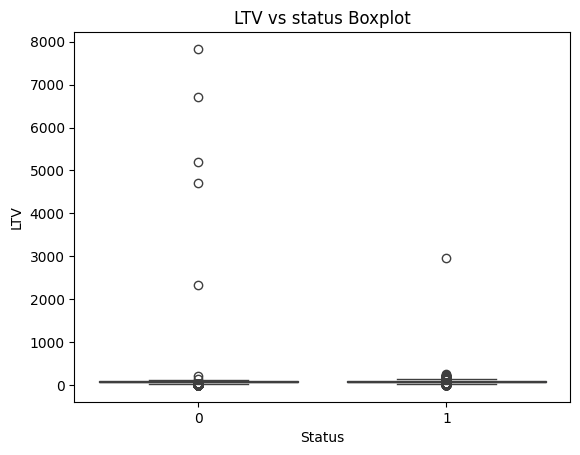

In [170]:
num_eda(df,"LTV")

result show data leakage as missing LTV serve as a proxy for default. this column will be removed from the data set .

* **dtir1**

dtir1 have 16.224524113809107% of null variable 
dtir1
False    0.163221
True     0.676174
Name: Status, dtype: float64
count    124549.000000
mean         37.732932
std          10.545435
min           5.000000
25%          31.000000
50%          39.000000
75%          45.000000
max          61.000000
Name: dtir1, dtype: float64


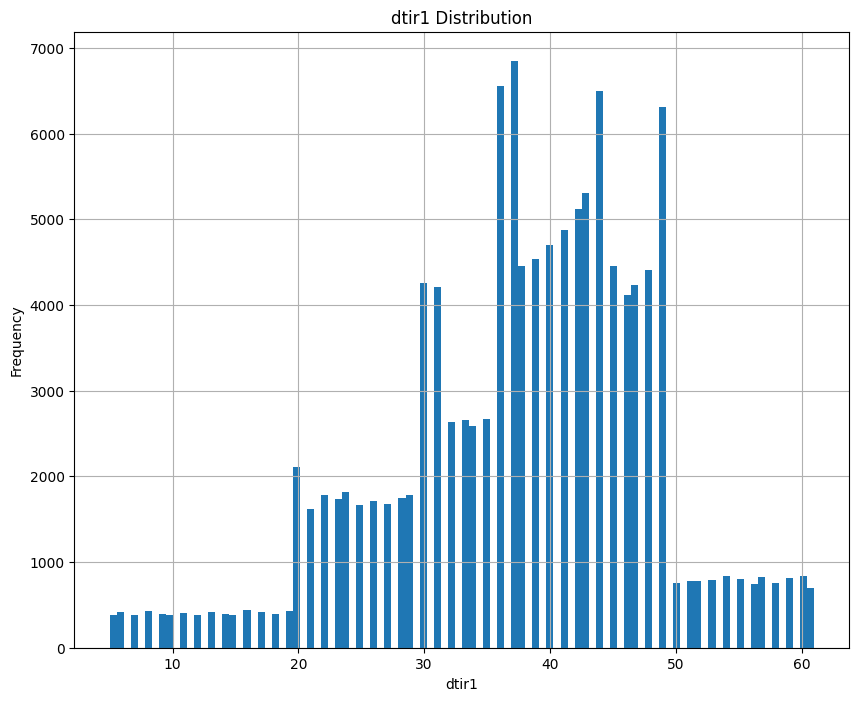

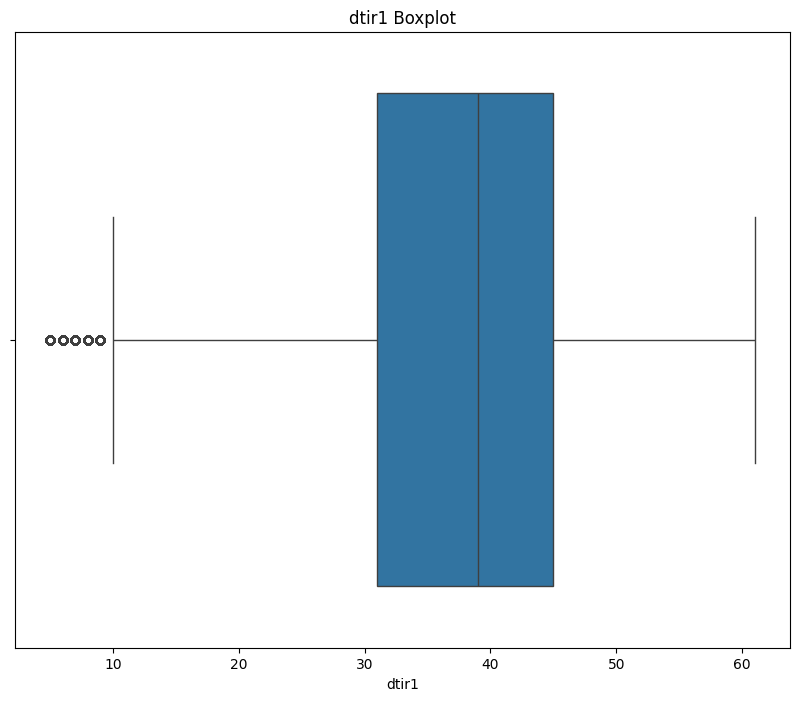

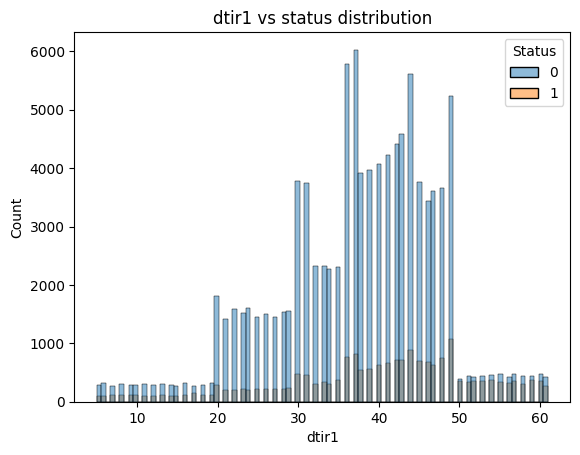

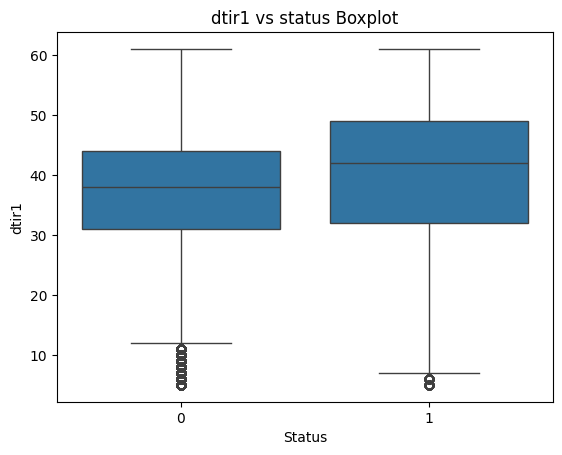

In [171]:
num_eda(df,"dtir1")

In [172]:
pd.crosstab(
    df["dtir1"].isnull(),
    df["rate_of_interest"].isnull()
)

rate_of_interest,False,True
dtir1,,
False,104220,20329
True,8011,16110


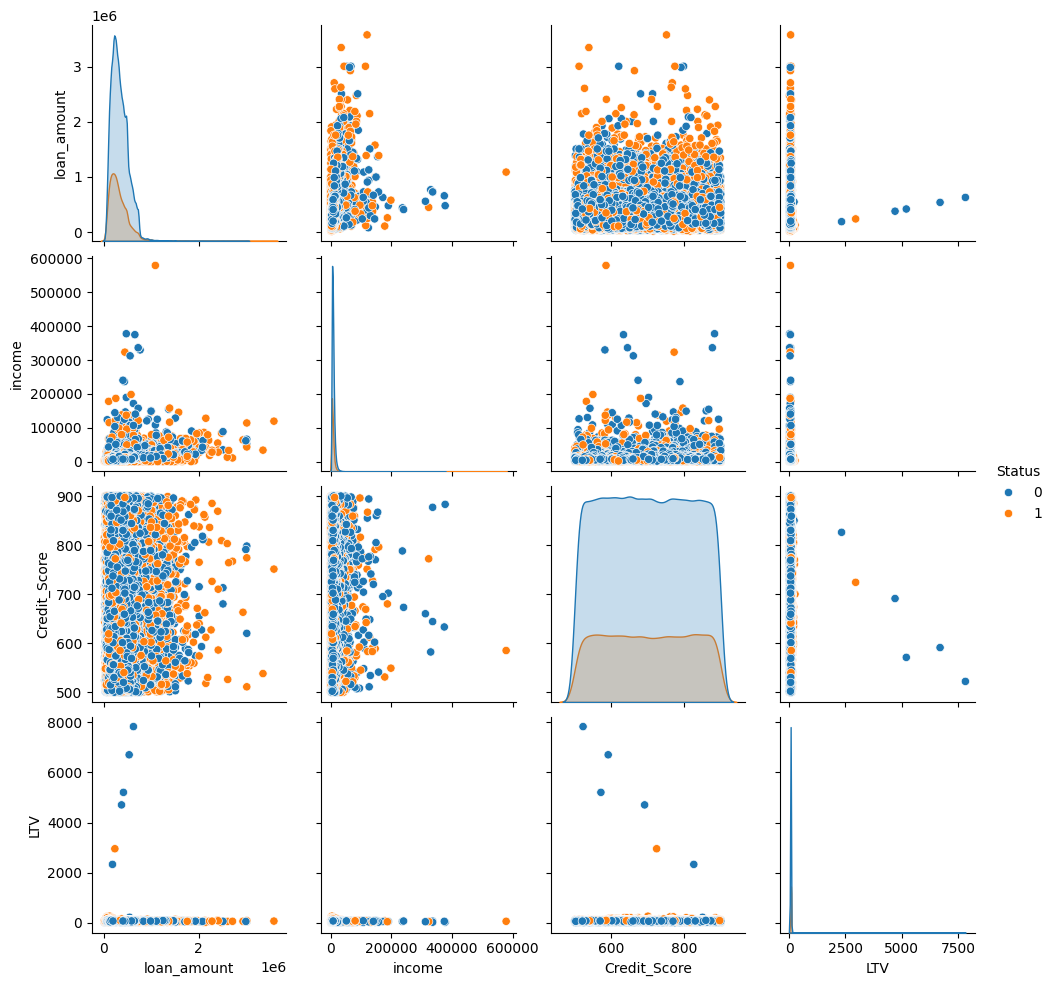

In [173]:
features = [
    'loan_amount',
    'income',
    'Credit_Score',
    'LTV',
    'Status'
]

sns.pairplot(df[features], hue='Status')

# categorical colomns 

loan_limit have 2.2492769220421067% of null variable 
loan_limit
False    0.246054
True     0.263457
Name: Status, dtype: float64


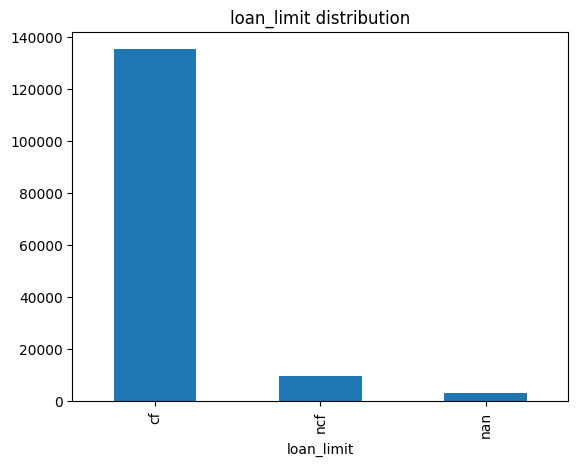

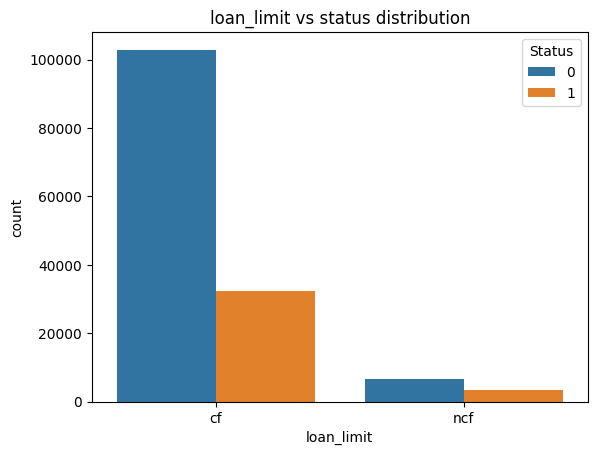

Gender have 0.0% of null variable 


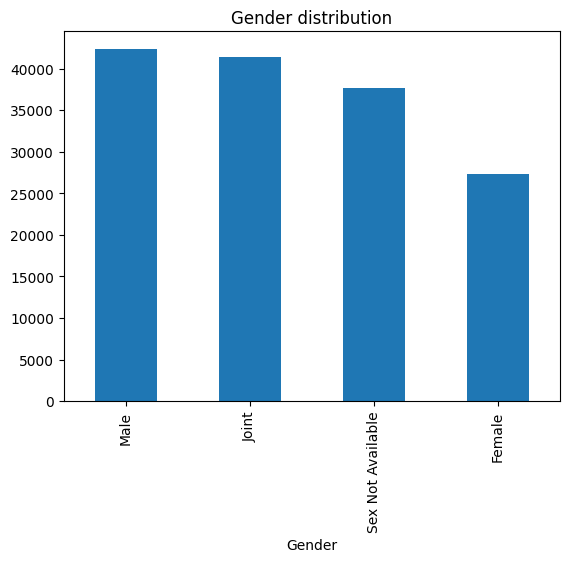

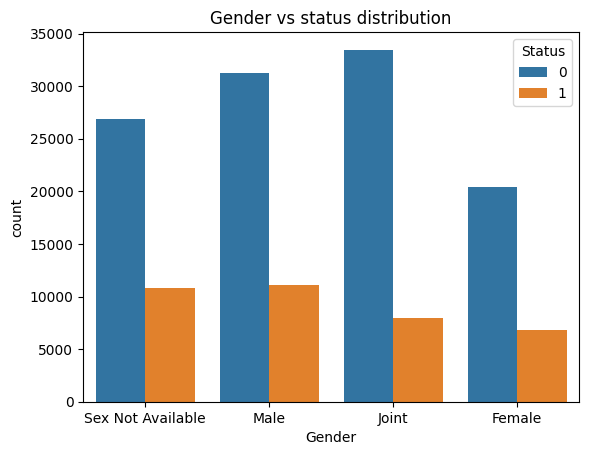

approv_in_adv have 0.6107486379229166% of null variable 
approv_in_adv
False    0.246329
True     0.265419
Name: Status, dtype: float64


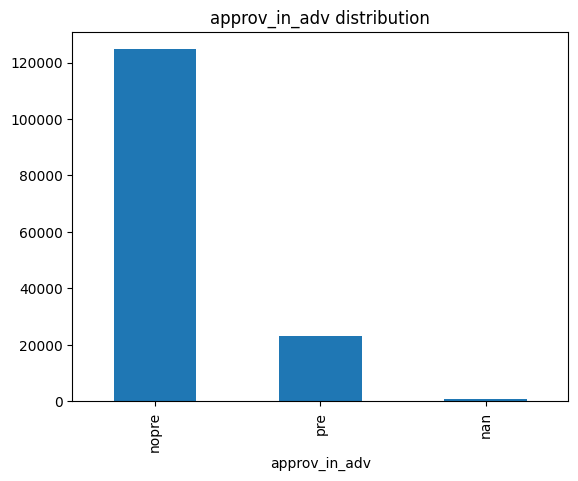

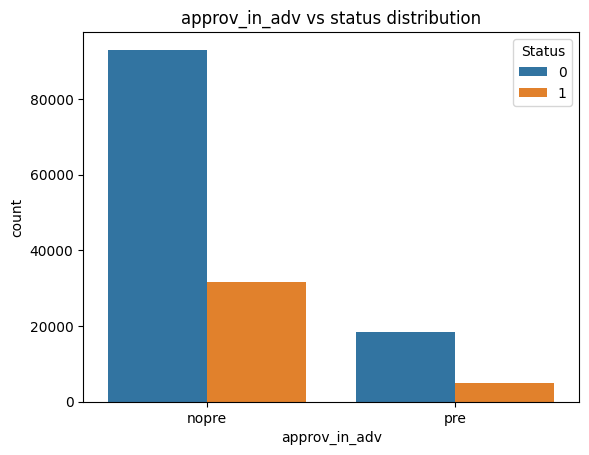

loan_type have 0.0% of null variable 


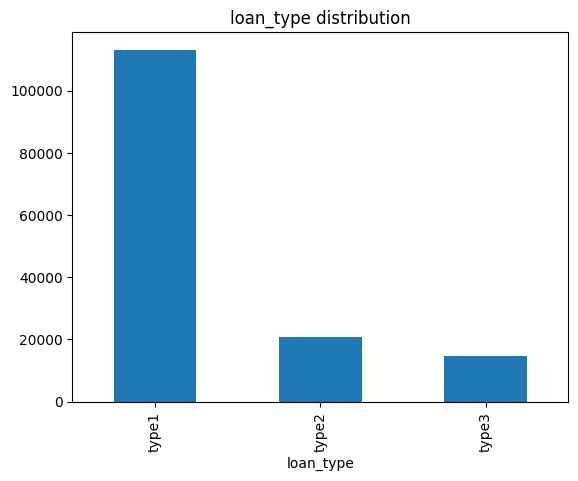

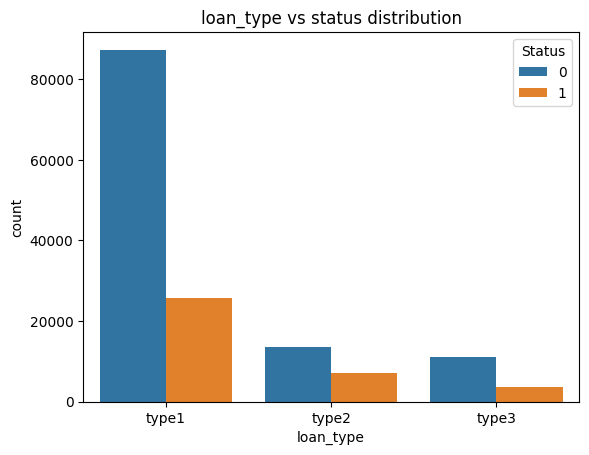

loan_purpose have 0.09013250823972557% of null variable 
loan_purpose
False    0.246432
True     0.261194
Name: Status, dtype: float64


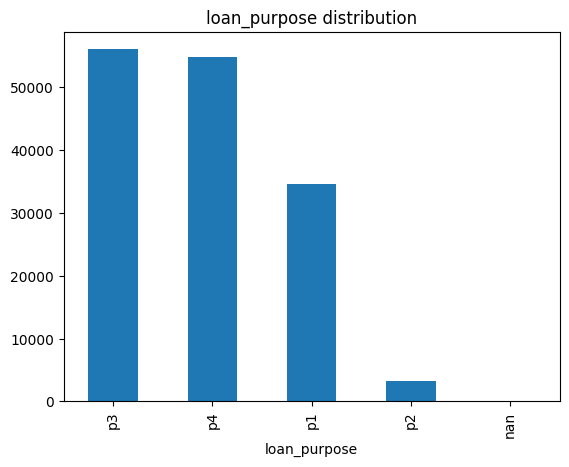

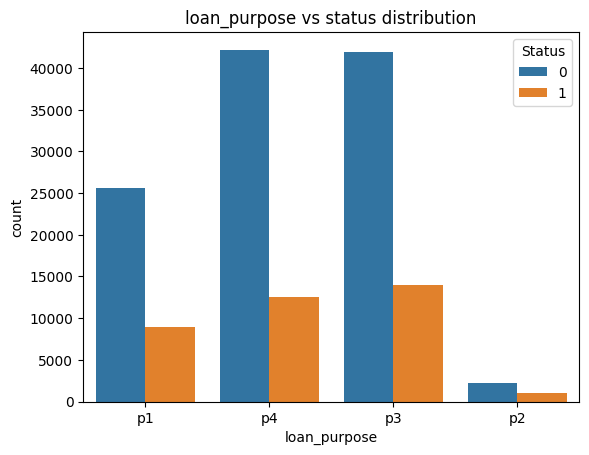

Credit_Worthiness have 0.0% of null variable 


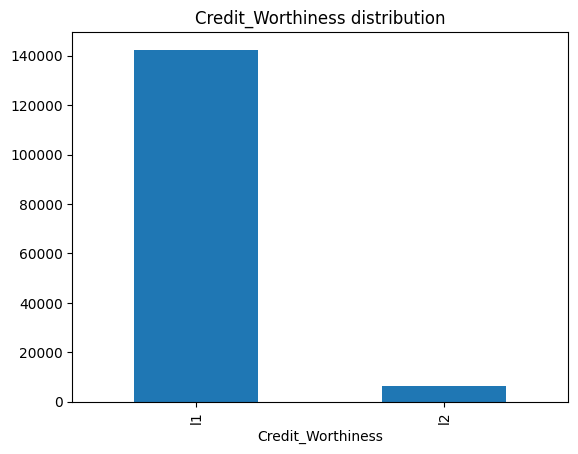

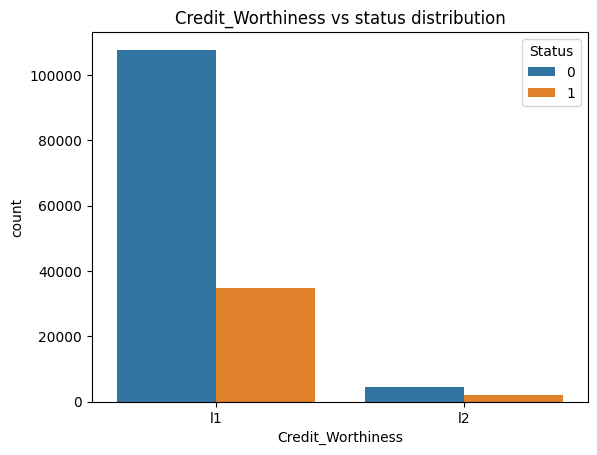

open_credit have 0.0% of null variable 


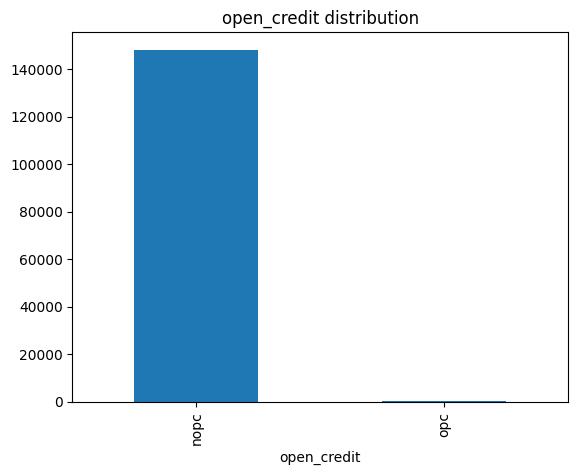

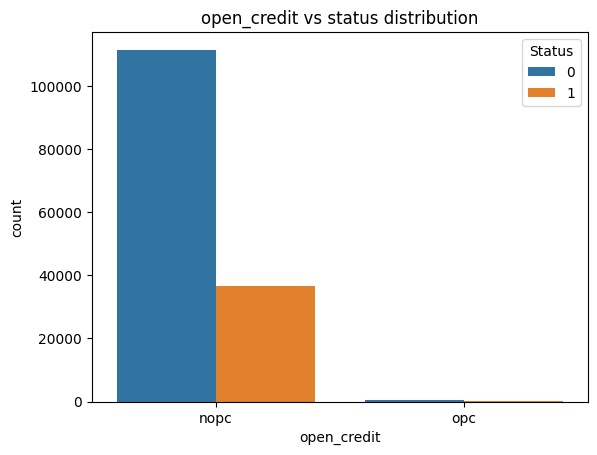

business_or_commercial have 0.0% of null variable 


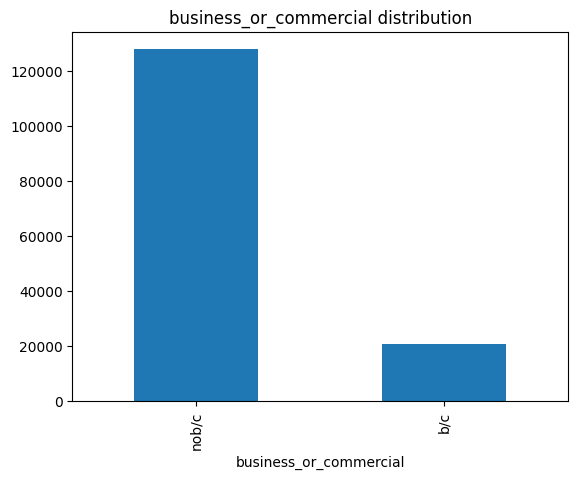

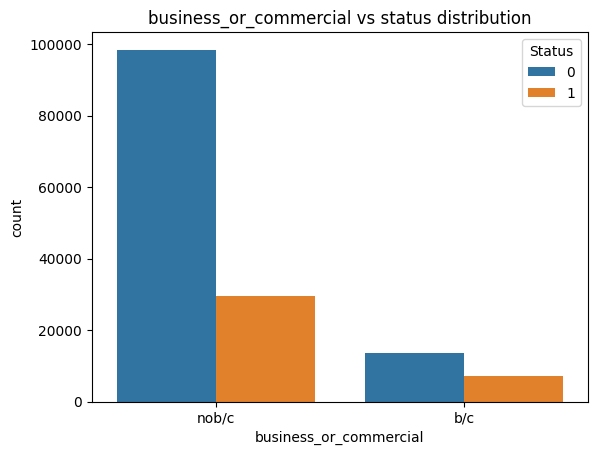

Neg_ammortization have 0.08138830967915517% of null variable 
Neg_ammortization
False    0.246430
True     0.264463
Name: Status, dtype: float64


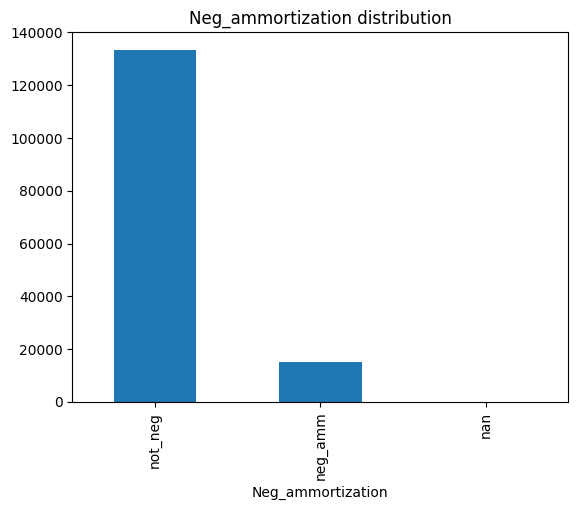

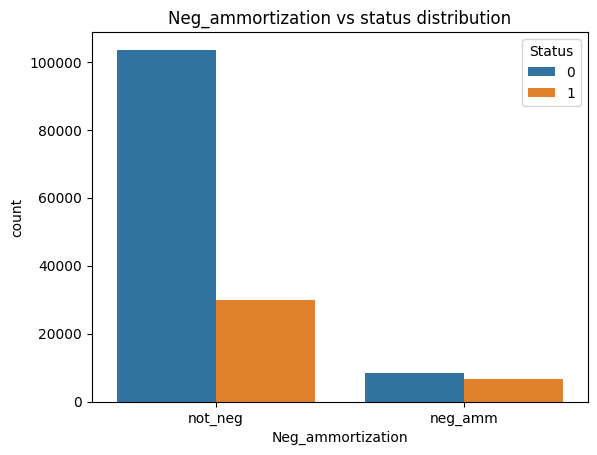

interest_only have 0.0% of null variable 


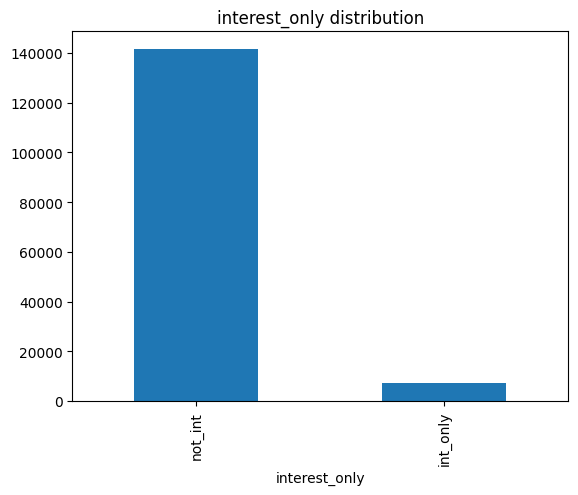

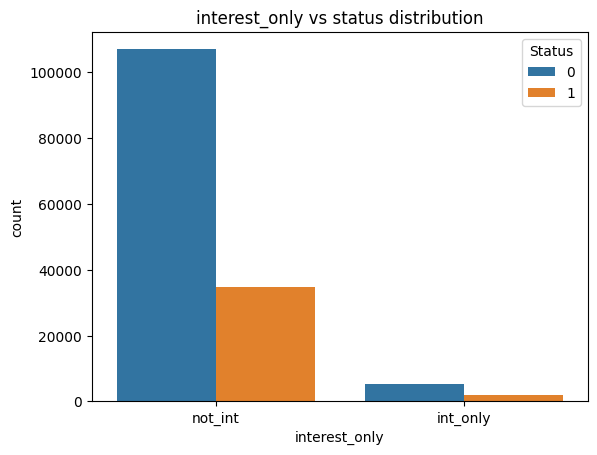

lump_sum_payment have 0.0% of null variable 


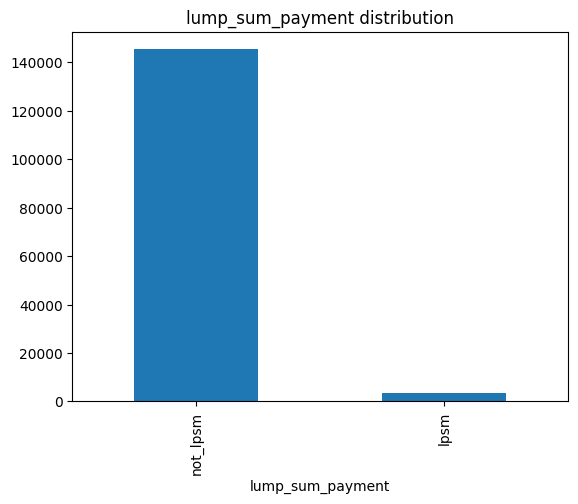

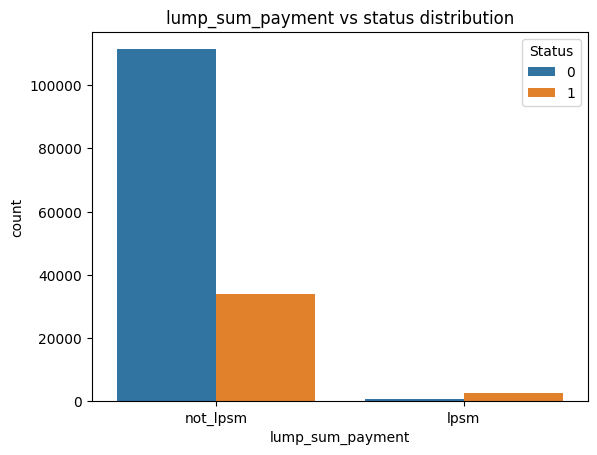

construction_type have 0.0% of null variable 


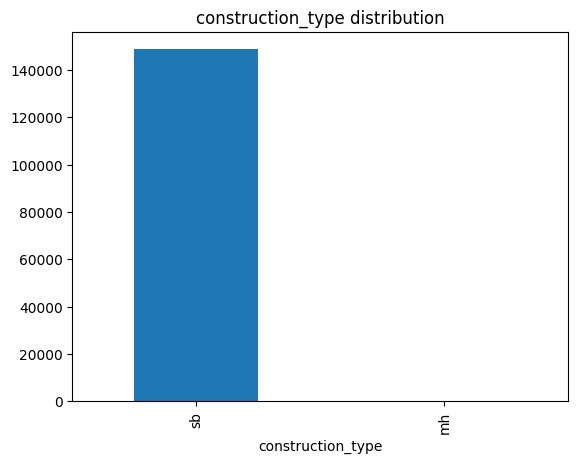

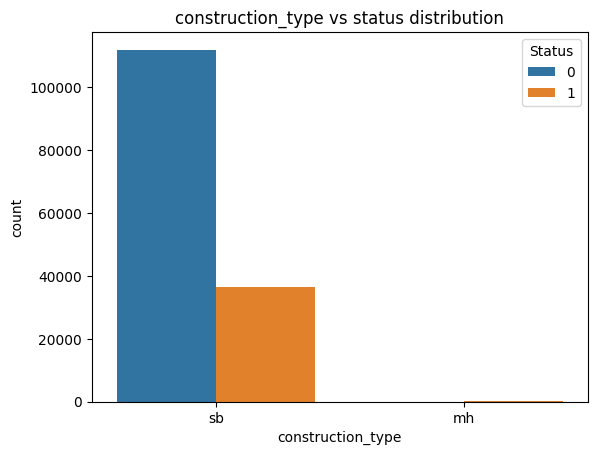

occupancy_type have 0.0% of null variable 


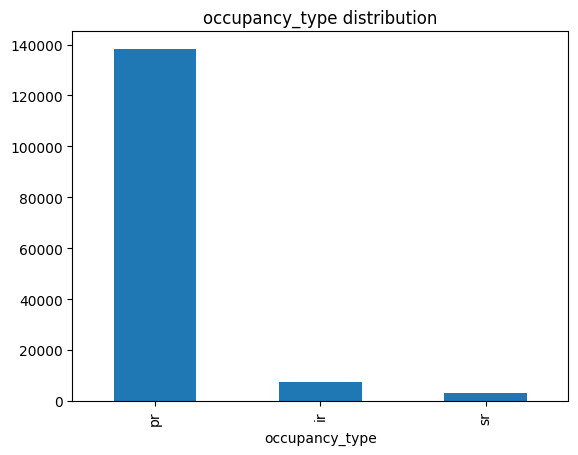

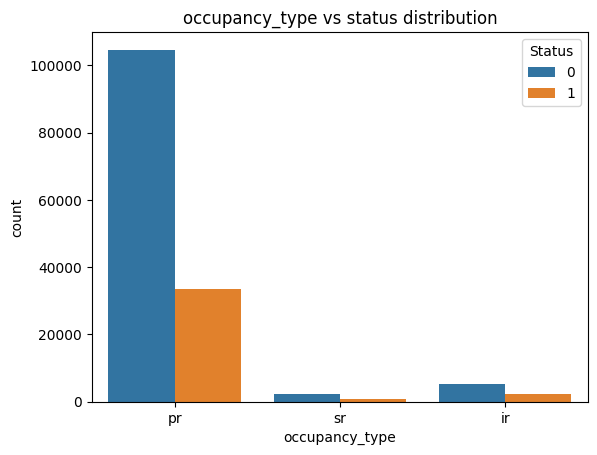

Secured_by have 0.0% of null variable 


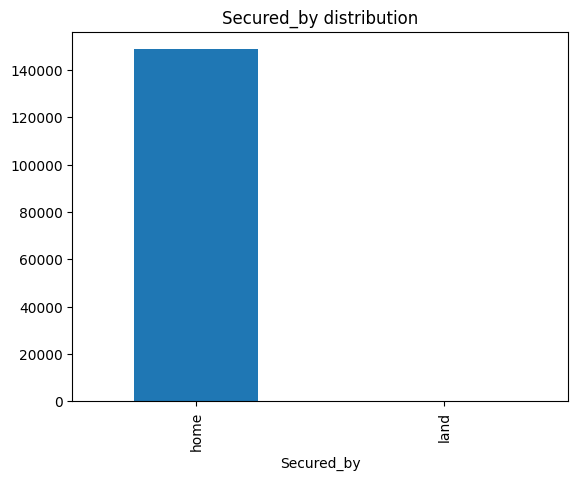

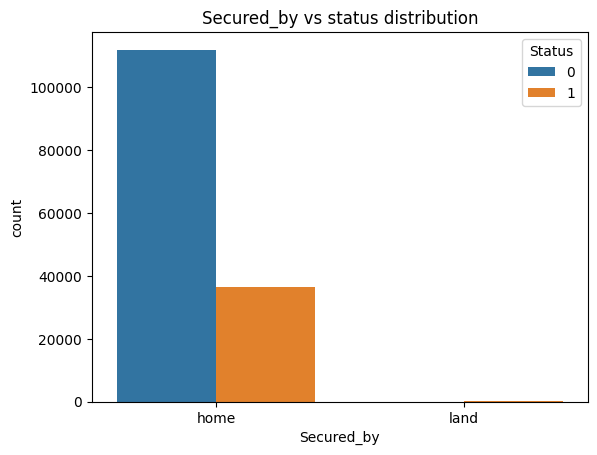

total_units have 0.0% of null variable 


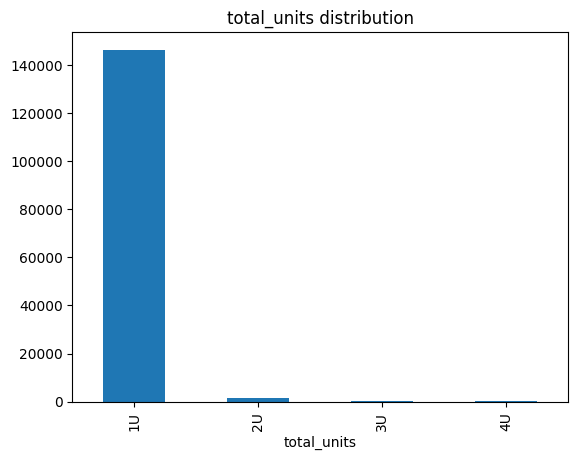

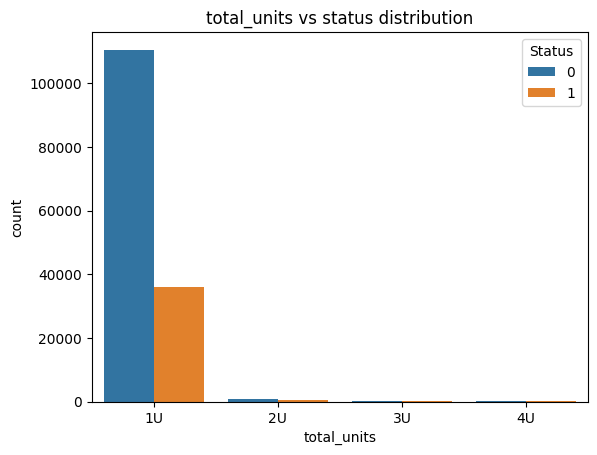

credit_type have 0.0% of null variable 


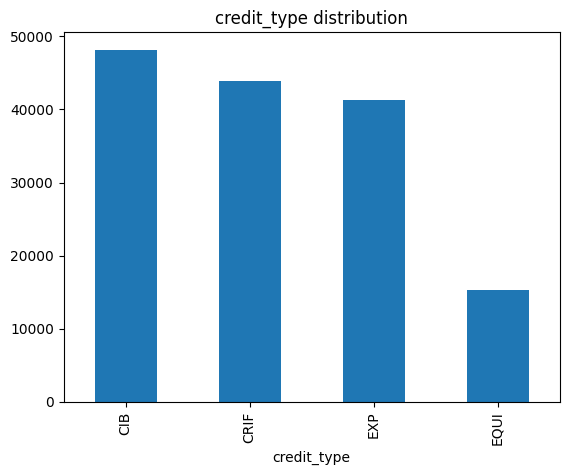

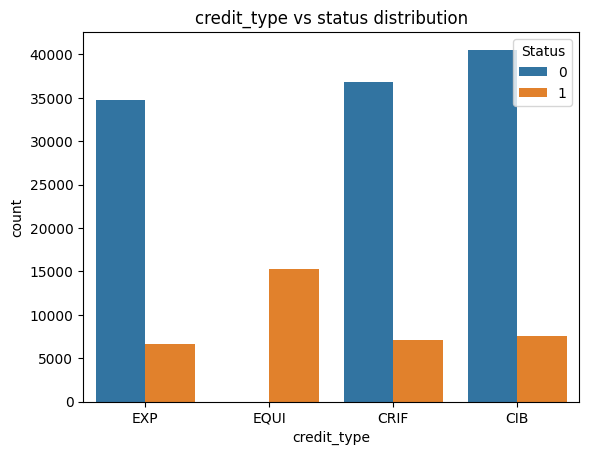

co-applicant_credit_type have 0.0% of null variable 


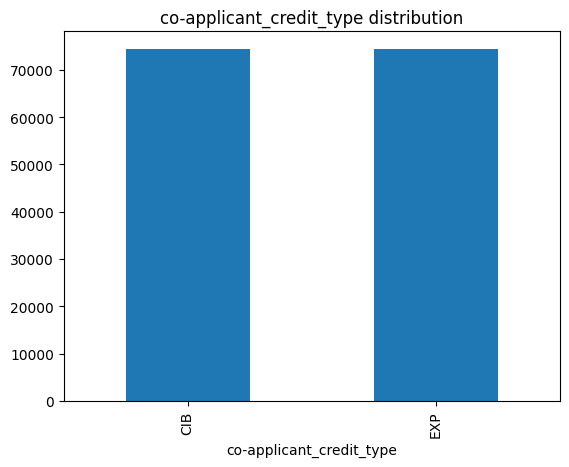

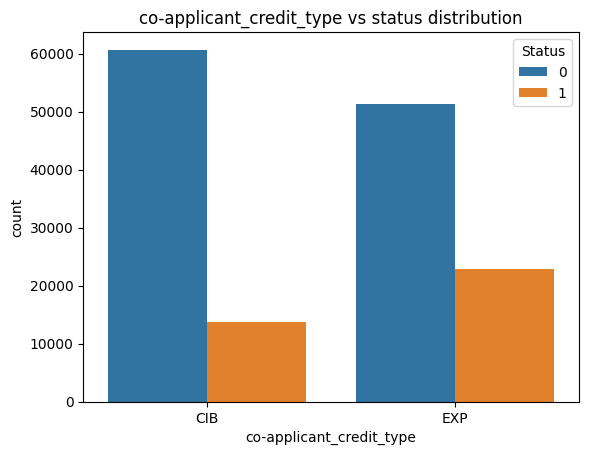

age have 0.13452613170108293% of null variable 
age
False    0.24543
True     1.00000
Name: Status, dtype: float64


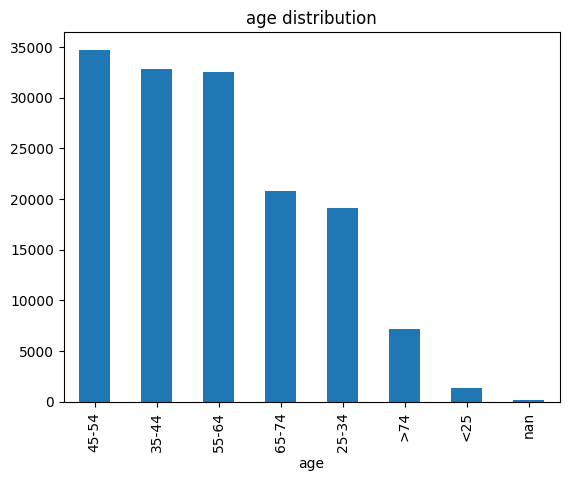

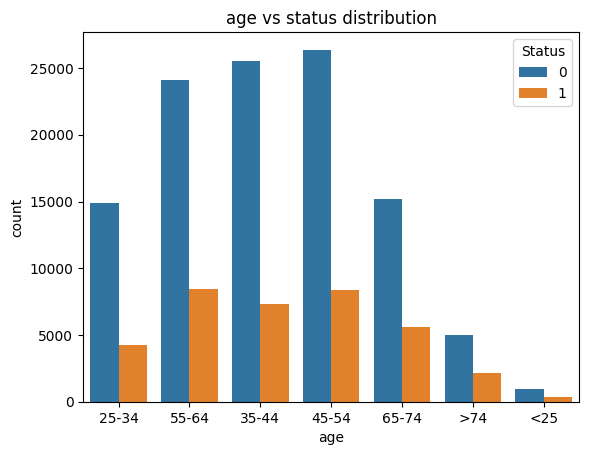

submission_of_application have 0.13452613170108293% of null variable 
submission_of_application
False    0.24543
True     1.00000
Name: Status, dtype: float64


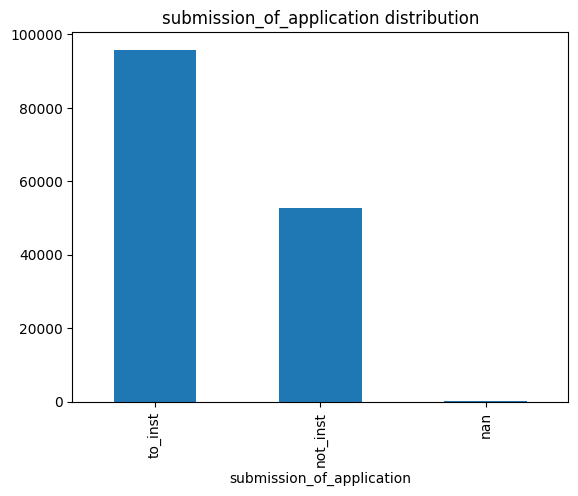

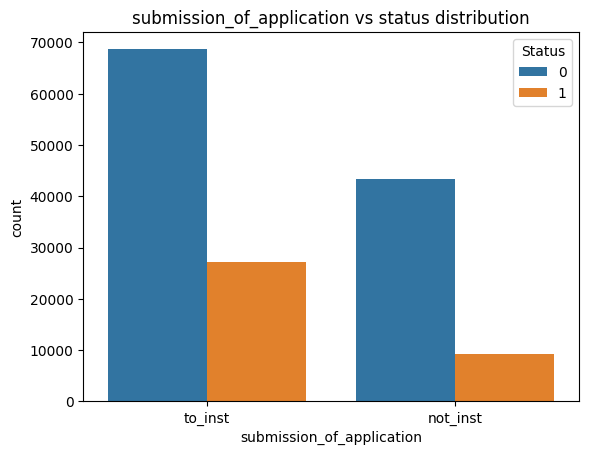

Region have 0.0% of null variable 


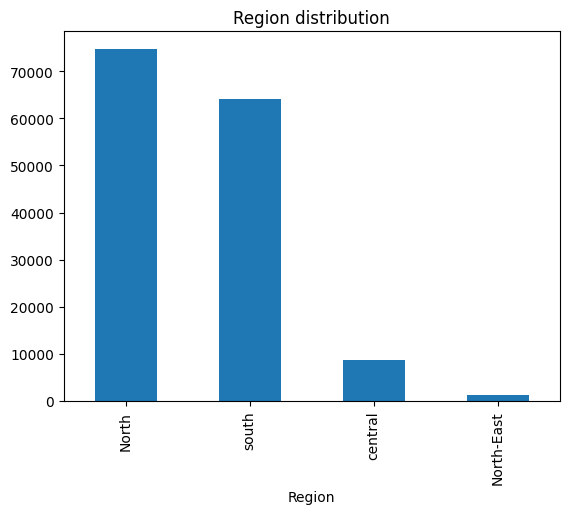

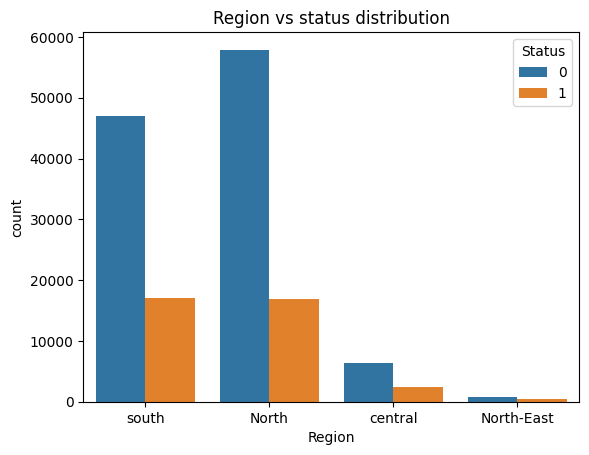

Security_Type have 0.0% of null variable 


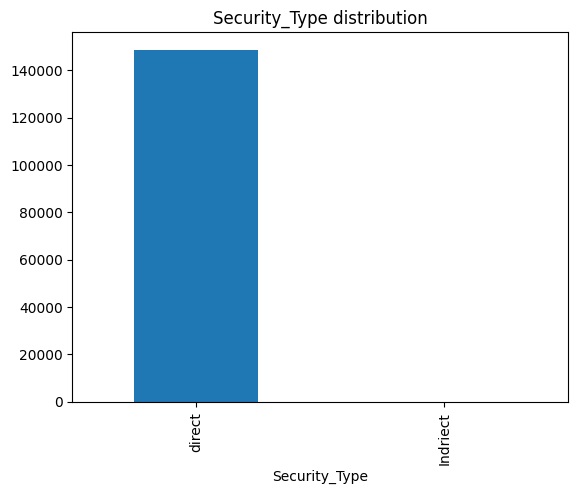

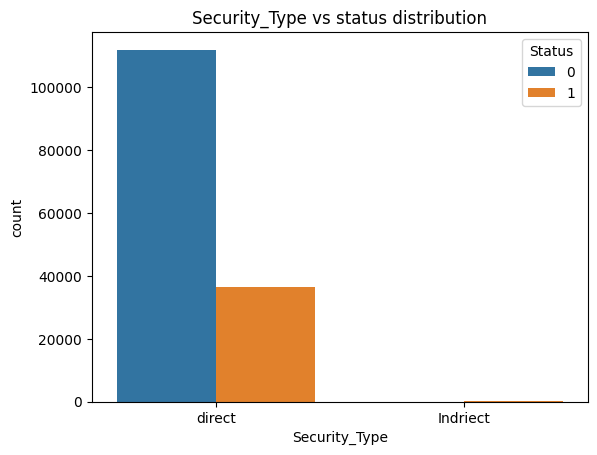

In [174]:
cat_cols=df.select_dtypes(exclude="number").columns

for col in cat_cols:
    num_eda(df,col)

* TERM

term have 0.027577856998722002% of null variable 
term
False    0.246412
True     0.365854
Name: Status, dtype: float64


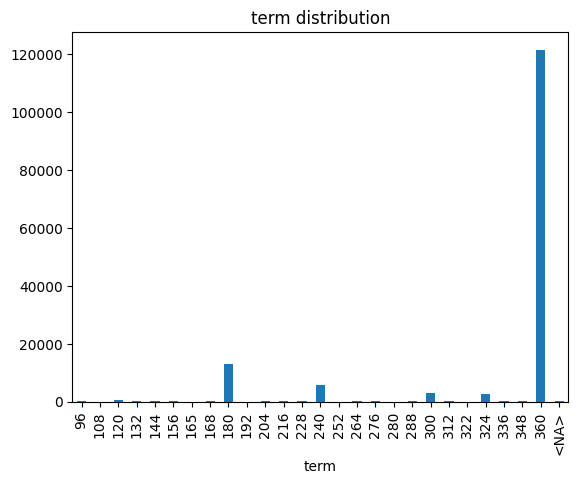

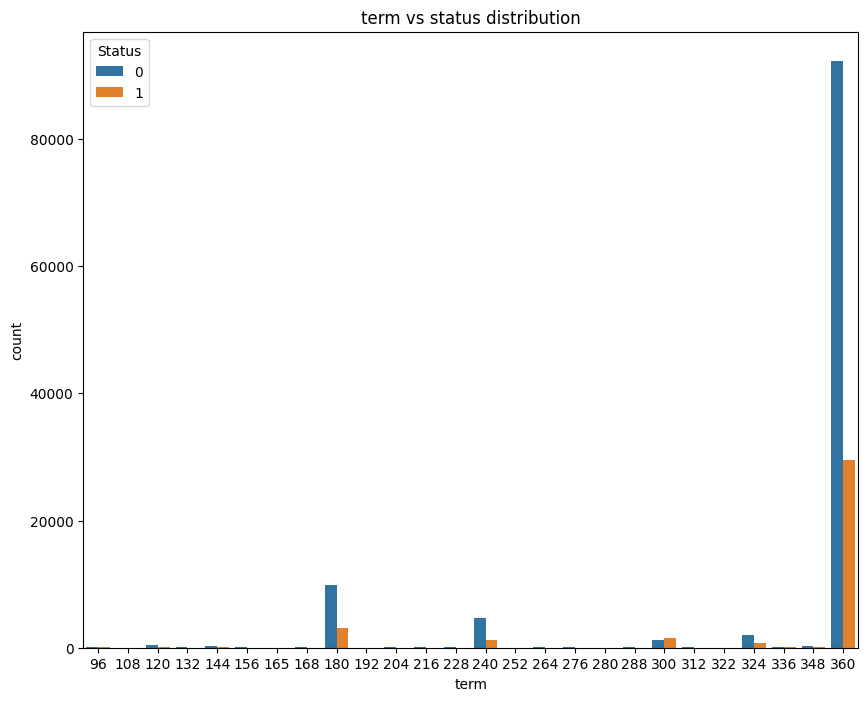

In [175]:
df["term"]=df["term"].astype("Int64")
print (f"{"term"} have {(df["term"].isna().mean()*100)}% of null variable ")
print(df.groupby(df["term"].isnull())["Status"].mean())
# plot a bar chart 
df["term"].value_counts(dropna=False).sort_index().plot(kind="bar")
plt.title(f"{"term"} distribution")
plt.show() 
       #######comparison vs status###########
plt.figure(figsize=(10, 8))
sns.countplot(x="term", hue='Status', data=df.sort_values("term"))
plt.title(f"{"term"} vs status distribution")
plt.show() 

# non numeric column 

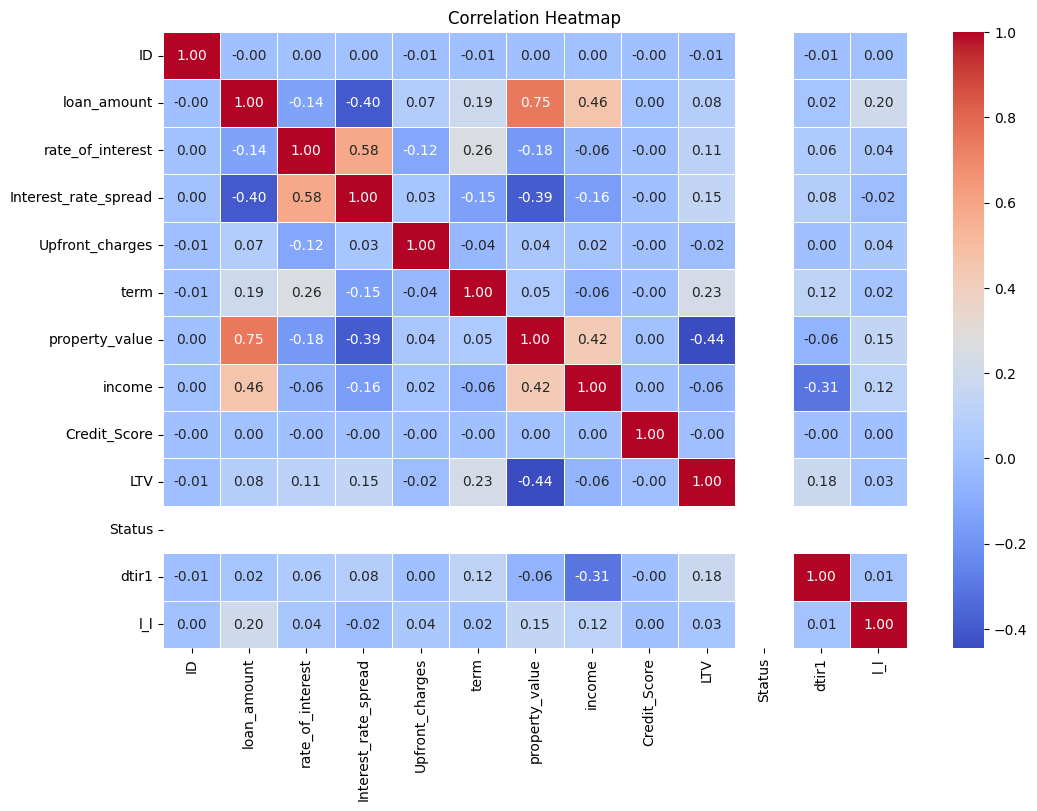

In [176]:
df["l_l"] = df["loan_limit"].apply(lambda x: 0 if x == "cf" else 1)
# Compute correlation matrix
corr = df.dropna().corr(numeric_only=True)

# Create figure
plt.figure(figsize=(12, 8))

# Heatmap
sns.heatmap(
    corr,
    annot=True,       # show correlation values
    cmap="coolwarm",  # color palette
    fmt=".2f",        # decimal formatting
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()